In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read cook county data and Evelyn results

In [2]:
data = pd.read_csv('../data/cook_county.csv')

/tmp/user/24606/ipykernel_3122108/2467070731.py:1: DtypeWarning: Columns (53) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/cook_county.csv')


In [5]:
data.columns.to_list()

['Unnamed: 0',
 'ASSESSED_YEAR',
 'CENSUS_ID',
 'fips',
 'MARKET_TOTAL_VALUE',
 'latitude',
 'longitude',
 'address',
 'TAX_YEAR',
 'TOTAL_TAX_AMOUNT',
 'NET_TAX_AMOUNT',
 'TAX_RATE_AREA_CODE',
 'meta_sfh',
 'char_yrblt',
 'char_yrblt_miss',
 'char_air_central',
 'char_air_miss',
 'char_air_cat',
 'char_beds',
 'char_beds_miss',
 'char_bldg_sf',
 'char_bldg_sf_miss',
 'char_ground_sf',
 'char_ground_sf_miss',
 'char_second_sf',
 'char_second_sf_miss',
 'char_base_fin_sf',
 'char_base_fin_sf_miss',
 'char_base_unfin_sf',
 'char_base_unfin_sf_miss',
 'char_stories',
 'char_stories_miss',
 'char_bsmt_miss',
 'char_no_bsmt',
 'char_bsmt_cel',
 'char_bsmt_slab',
 'char_bsmt_cat',
 'car_bsmt_fin_miss',
 'char_bsmt_fin_par',
 'char_basement_unfin',
 'char_bsmt_fin_cat',
 'char_ext_wall_miss',
 'char_ext_wall_cat',
 'char_nbath',
 'char_nbath_miss',
 'char_fbath',
 'char_fbath_miss',
 'char_hbath',
 'char_hbath_miss',
 'char_has_frpl',
 'char_n_frpl',
 'char_n_frpl_miss',
 'char_gar1_cnst_miss

In [18]:
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(data['SALE_AMOUNT'].describe())

count       211,528.000000
mean        413,776.381756
std       1,567,510.995865
min           5,300.000000
25%         190,000.000000
50%         282,000.000000
75%         420,000.000000
max     175,000,000.000000
Name: SALE_AMOUNT, dtype: float64


In [18]:
data.shape

(211528, 143)

In [22]:
test_set = data[data['SALE_YEAR'] == 2022].copy()
test_set.shape

(40333, 143)

In [28]:
data[data['SALE_YEAR'] == 2021].shape

(49364, 143)

In [74]:
data.head()

,Unnamed: 0,ASSESSED_YEAR,CENSUS_ID,fips,MARKET_TOTAL_VALUE,latitude,longitude,address,TAX_YEAR,TOTAL_TAX_AMOUNT,...,census_pct_graduate_bg,census_pct_poverty_bg,census_med_hh_inc_bg,census_med_per_cap_inc_bg,census_pct_snap_bg,census_unemp_rate_bg,census_med_yr_built_bg,census_pct_renter_occ_bg,census_med_rent_bg,block_group_id
0,12390,2018,8.107011e+09,17031.0,188650.0,41.933900,-87.812359,2937 N 74TH CT,2018.0,5009.71,...,0.000000,0.149425,94167.0,34796.0,0.071839,0.073529,1956.0,0.465517,1221.0,1.703181e+11
1,12391,2019,8.041041e+09,17031.0,409170.0,42.102207,-88.102472,4325 EISENHOWER CIR,2019.0,2190.13,...,0.137710,0.026446,157426.0,65397.0,0.046281,0.026484,1975.0,0.795041,3272.0,1.703180e+11
2,12392,2019,8.300051e+09,17031.0,184320.0,41.511599,-87.711221,800 CUMNOCK RD,2019.0,9659.05,...,0.186658,0.173673,88269.0,52694.0,0.068584,0.025961,1985.0,0.762168,3448.0,1.703183e+11
3,12393,2018,6.108001e+09,17031.0,200170.0,41.811101,-87.637652,444 W 46TH ST,2018.0,3954.00,...,0.026388,0.090461,125250.0,46077.0,0.100329,0.069414,NaN,0.720395,1329.0,1.703161e+11
4,12394,2018,8.207001e+09,17031.0,95370.0,41.820340,-87.788452,3927 CLARENCE AVE,2018.0,2550.66,...,0.171403,0.141831,85995.0,33886.0,0.000000,0.140309,1955.0,1.000000,NaN,1.703182e+11


In [76]:
data.columns.to_list()

['Unnamed: 0',
 'ASSESSED_YEAR',
 'CENSUS_ID',
 'fips',
 'MARKET_TOTAL_VALUE',
 'latitude',
 'longitude',
 'address',
 'TAX_YEAR',
 'TOTAL_TAX_AMOUNT',
 'NET_TAX_AMOUNT',
 'TAX_RATE_AREA_CODE',
 'meta_sfh',
 'char_yrblt',
 'char_yrblt_miss',
 'char_air_central',
 'char_air_miss',
 'char_air_cat',
 'char_beds',
 'char_beds_miss',
 'char_bldg_sf',
 'char_bldg_sf_miss',
 'char_ground_sf',
 'char_ground_sf_miss',
 'char_second_sf',
 'char_second_sf_miss',
 'char_base_fin_sf',
 'char_base_fin_sf_miss',
 'char_base_unfin_sf',
 'char_base_unfin_sf_miss',
 'char_stories',
 'char_stories_miss',
 'char_bsmt_miss',
 'char_no_bsmt',
 'char_bsmt_cel',
 'char_bsmt_slab',
 'char_bsmt_cat',
 'car_bsmt_fin_miss',
 'char_bsmt_fin_par',
 'char_basement_unfin',
 'char_bsmt_fin_cat',
 'char_ext_wall_miss',
 'char_ext_wall_cat',
 'char_nbath',
 'char_nbath_miss',
 'char_fbath',
 'char_fbath_miss',
 'char_hbath',
 'char_hbath_miss',
 'char_has_frpl',
 'char_n_frpl',
 'char_n_frpl_miss',
 'char_gar1_cnst_miss

In [40]:
data['block_group_id'].nunique()

3818

In [59]:
(data['block_group_id'].value_counts() >= 200).sum() #.describe()

np.int64(40)

In [14]:
data['SALIL_AJDUSTED_CALCULATED_TOTAL_VALUE'] = data['CALCULATED_TOTAL_VALUE'] / (data['CALCULATED_TOTAL_VALUE'] / data['SALE_AMOUNT']).median()

In [15]:
data[['SALE_AMOUNT', 'SALIL_AJDUSTED_CALCULATED_TOTAL_VALUE']]

,SALE_AMOUNT,SALIL_AJDUSTED_CALCULATED_TOTAL_VALUE
0,227000.0,231982.883032
1,420000.0,503156.301353
2,350000.0,226658.282536
3,280000.0,246149.025691
4,132500.0,117276.477894
...,...,...
211523,85000.0,78393.367576
211524,335000.0,259688.021409
211525,195000.0,44502.838786
211526,195000.0,44502.838786


In [11]:
with pd.option_context('display.float_format', '{:,.3f}'.format):
    print((data['CALCULATED_TOTAL_VALUE'] / data['SALE_AMOUNT']).describe())#.median()

count   211,528.000
mean          0.087
std           0.152
min           0.000
25%           0.066
50%           0.081
75%           0.098
max          62.113
dtype: float64


In [2]:
df = pd.read_csv('cook_county_scarcity_results.csv')

In [3]:
df

,seed,train_size,n_test,mae,mse,r2,mean_ratio,median_ratio,train_time,pred_time,status
0,0,25,39383,NaN,NaN,NaN,NaN,NaN,NaN,NaN,failed: could not convert string to float: '__...
1,0,50,39383,144085.094956,2.421932e+12,0.092666,1.130160,1.031814,0.608096,23.670287,success
2,0,75,39383,143936.051800,2.444907e+12,0.084059,1.064045,0.988808,0.673186,33.433561,success
3,0,100,39383,142194.254001,2.423127e+12,0.092219,1.053373,0.976709,0.660428,35.477627,success
4,0,125,39383,146150.566320,2.437545e+12,0.086817,1.064247,0.967849,0.528623,121.421123,success
...,...,...,...,...,...,...,...,...,...,...,...
175,4,400,39383,151261.070123,2.372774e+12,0.111082,1.258744,1.107671,0.923895,33.795323,success
176,4,425,39383,149049.257226,2.392462e+12,0.103706,1.245952,1.096491,1.021654,33.437880,success
177,4,450,39383,151465.676096,2.405193e+12,0.098937,1.262578,1.109582,1.130153,42.283689,success
178,4,475,39383,148013.257821,2.399454e+12,0.101087,1.224428,1.083820,1.111331,43.348456,success


In [6]:
df[df['train_size'] == 75]

,seed,train_size,n_test,mae,mse,r2,mean_ratio,median_ratio,train_time,pred_time,status
2,0,75,39383,143936.051800,2.444907e+12,0.084059,1.064045,0.988808,0.673186,33.433561,success
42,1,75,39383,246398.818419,2.417215e+12,0.094433,1.536161,1.361494,0.601466,31.379943,success
82,2,75,39383,143208.194132,2.407132e+12,0.098211,1.031280,0.954704,0.630139,34.650765,success
122,3,75,39383,160691.589694,2.352926e+12,0.118518,1.199790,1.097160,0.618505,32.983462,success
162,4,75,39383,155936.495680,2.390183e+12,0.104560,1.090741,0.987367,0.623994,34.842390,success


In [12]:
df[df['train_size'] == 400]

,seed,train_size,n_test,mae,mse,r2,mean_ratio,median_ratio,train_time,pred_time,status
15,0,400,39383,143293.048997,2.042180e+12,0.234934,1.182832,1.077528,0.848673,33.637480,success
55,1,400,39383,145114.426599,2.280348e+12,0.145708,1.145142,1.043804,0.895844,24.485701,success
95,2,400,39383,195355.948720,2.265538e+12,0.151257,1.509876,1.263073,1.063112,24.591158,success
135,3,400,39383,171963.138304,2.210235e+12,0.171975,1.346298,1.190876,0.876814,24.679083,success
175,4,400,39383,151261.070123,2.372774e+12,0.111082,1.258744,1.107671,0.923895,33.795323,success


# helper functions

In [2]:
def get_tabpfn_xgboost_comparison(tabpfn, xgboost):
    # Aggregate over seeds per train_size and compare TabPFN vs XGBoost
    metrics = ['mae', 'mse', 'r2', 'mean_ratio', 'median_ratio', 'std_ratio']

    # Filter to successful runs
    _tab = tabpfn #tabpfn[tabpfn['status'] == 'success'].copy()
    _xgb = xgboost #xgboost[xgboost['status'] == 'success'].copy()

    # Aggregate: mean/std/count across seeds for each train_size
    agg_funcs = {m: ['mean', 'std'] for m in metrics}
    agg_funcs['seed'] = 'count'

    agg_tab = (
        _tab.groupby('train_size')
            .agg(agg_funcs)
            .rename_axis(index=None)
    )
    agg_xgb = (
        _xgb.groupby('train_size')
            .agg(agg_funcs)
            .rename_axis(index=None)
    )

    # Flatten multiindex columns
    agg_tab.columns = ['tabpfn__' + ('count' if c == 'seed' else f"{m}_{c}") for (m, c) in agg_tab.columns]
    agg_xgb.columns = ['xgboost__' + ('count' if c == 'seed' else f"{m}_{c}") for (m, c) in agg_xgb.columns]

    # Join on train_size
    comparison = (
        agg_tab.merge(agg_xgb, left_index=True, right_index=True, how='outer')
            .sort_index()
    )
    comparison.index.name = 'train_size'

    # Compute deltas for a few key metrics (TabPFN minus XGBoost)
    for m in ['mae', 'mse', 'r2', 'mean_ratio', 'median_ratio', 'std_ratio']:
        if f'tabpfn__{m}_mean' in comparison.columns and f'xgboost__{m}_mean' in comparison.columns:
            comparison[f'delta__{m}_mean'] = comparison[f'tabpfn__{m}_mean'] - comparison[f'xgboost__{m}_mean']

    # Display compact view of key metrics
    cols_to_show = []
    for m in ['mae', 'mse', 'r2', 'mean_ratio', 'median_ratio', 'std_ratio']:
        for model in ['tabpfn', 'xgboost']:
            for stat in ['mean', 'std']:
                col = f'{model}__{m}_{stat}'
                if col in comparison.columns:
                    cols_to_show.append(col)
    for d in ['delta__mae_mean', 'delta__mse_mean', 'delta__r2_mean', 'delta__mean_ratio_mean', 'delta__median_ratio_mean', 'delta__std_ratio_mean']:
        if d in comparison.columns:
            cols_to_show.append(d)

    return comparison, cols_to_show


In [3]:
def make_comparison_plot(comparison, item, yline=None, plot_tabpfn_line=True, plot_xgboost_line=True, show_std=True, test_set='All Cook County'):
    fig, ax = plt.subplots(figsize=(8,4))
    ts = comparison.index.values
    if plot_tabpfn_line:
        
        if show_std:
            if f'tabpfn__{item}_mean' in comparison and f'tabpfn__{item}_std' in comparison:
                ax.errorbar(ts, comparison[f'tabpfn__{item}_mean'], yerr=comparison[f'tabpfn__{item}_std'], label='TabPFN', fmt='-o', capsize=4)
        else:
            ax.plot(ts, comparison[f'tabpfn__{item}_mean'], label='TabPFN', linestyle='-', marker='o')
    
    if plot_xgboost_line:
        
        if show_std:
            if f'xgboost__{item}_mean' in comparison and f'xgboost__{item}_std' in comparison:
                ax.errorbar(ts, comparison[f'xgboost__{item}_mean'], yerr=comparison[f'xgboost__{item}_std'], label='XGBoost', fmt='-o', capsize=4)
        else:
            ax.plot(ts, comparison[f'xgboost__{item}_mean'], label='XGBoost', linestyle='-', marker='o')

    ax.set_xlabel('train_size')
    ax.set_ylabel(f'{item} (mean ± std across seeds)')
    ax.set_title(f'{item} comparison, test set: {test_set}')
    ax.grid(True)

    if yline is not None:
        ax.axhline(yline, color='k', linestyle='--', alpha=0.7, label=f'y={yline}')
    ax.legend()
    plt.tight_layout()
    plt.show()

# TabPFN vs XGBoost 4 seeds train sizes 25, 50, .., 1000 results comparison

In [47]:
tabpfn = pd.read_csv('results/tabpfn_full.csv')
xgboost = pd.read_csv('results/xgboost_full.csv')

In [36]:
train_size = 25

In [37]:
tabpfn[tabpfn['train_size'] == train_size]

,seed,train_size,test_type,n_train,n_test,n_train_cbgs,n_test_cbgs,mae,mse,r2,mean_ratio,median_ratio,std_ratio,train_time,pred_time,status
0,0,25,cbg_matched,25,408,24,24,120329.959425,7.385449e+10,0.487361,0.976131,0.930483,0.387208,9.086970,0.239589,success
40,1,25,cbg_matched,25,463,25,24,267828.014832,2.730829e+11,0.117696,1.811032,1.304314,1.986514,0.511931,0.224861,success
80,2,25,cbg_matched,25,395,25,23,70876.529747,1.066499e+10,0.787315,1.004426,0.914414,0.368455,0.513311,0.210708,success
120,3,25,cbg_matched,25,422,25,24,114634.970250,7.788218e+10,0.230234,0.944749,0.938274,0.446431,0.490580,0.211498,success


In [38]:
xgboost[xgboost['train_size'] == train_size]

,seed,train_size,test_type,n_train,n_test,n_train_cbgs,n_test_cbgs,mae,mse,r2,mean_ratio,median_ratio,std_ratio,train_time,pred_time,status,tune_time
0,0,25,cbg_matched,25,408,24,24,168756.003332,1.267594e+11,0.120137,0.963229,0.860984,0.570386,7.657911,0.016883,success,6.734222
40,1,25,cbg_matched,25,463,25,24,251240.509618,2.681536e+11,0.133622,1.734020,1.337396,1.917848,5.721037,0.013784,success,5.720177
80,2,25,cbg_matched,25,395,25,23,92491.939755,2.226513e+10,0.555981,0.986757,0.899180,0.379701,5.722849,0.013602,success,5.721964
120,3,25,cbg_matched,25,422,25,24,121156.264662,5.950367e+10,0.411882,0.921577,0.841018,1.018534,5.868547,0.017279,success,5.867847


In [48]:
# Aggregate over seeds per train_size and compare TabPFN vs XGBoost
metrics = ['mae', 'mse', 'r2', 'mean_ratio', 'median_ratio', 'std_ratio']

# Filter to successful runs
_tab = tabpfn[tabpfn['status'] == 'success'].copy()
_xgb = xgboost[xgboost['status'] == 'success'].copy()

# Aggregate: mean/std/count across seeds for each train_size
agg_funcs = {m: ['mean', 'std'] for m in metrics}
agg_funcs['seed'] = 'count'

agg_tab = (
    _tab.groupby('train_size')
        .agg(agg_funcs)
        .rename_axis(index=None)
)
agg_xgb = (
    _xgb.groupby('train_size')
        .agg(agg_funcs)
        .rename_axis(index=None)
)

# Flatten multiindex columns
agg_tab.columns = ['tabpfn__' + ('count' if c == 'seed' else f"{m}_{c}") for (m, c) in agg_tab.columns]
agg_xgb.columns = ['xgboost__' + ('count' if c == 'seed' else f"{m}_{c}") for (m, c) in agg_xgb.columns]

# Join on train_size
comparison = (
    agg_tab.merge(agg_xgb, left_index=True, right_index=True, how='outer')
           .sort_index()
)
comparison.index.name = 'train_size'

# Compute deltas for a few key metrics (TabPFN minus XGBoost)
for m in ['mae', 'mse', 'r2', 'mean_ratio', 'median_ratio', 'std_ratio']:
    if f'tabpfn__{m}_mean' in comparison.columns and f'xgboost__{m}_mean' in comparison.columns:
        comparison[f'delta__{m}_mean'] = comparison[f'tabpfn__{m}_mean'] - comparison[f'xgboost__{m}_mean']

# Display compact view of key metrics
cols_to_show = []
for m in ['mae', 'mse', 'r2', 'mean_ratio', 'median_ratio', 'std_ratio']:
    for model in ['tabpfn', 'xgboost']:
        for stat in ['mean', 'std']:
            col = f'{model}__{m}_{stat}'
            if col in comparison.columns:
                cols_to_show.append(col)
for d in ['delta__mae_mean', 'delta__mse_mean', 'delta__r2_mean', 'delta__mean_ratio_mean', 'delta__median_ratio_mean', 'delta__std_ratio_mean']:
    if d in comparison.columns:
        cols_to_show.append(d)

with pd.option_context('display.float_format', '{:,.3f}'.format):
    display(comparison[cols_to_show])


,tabpfn__mae_mean,tabpfn__mae_std,xgboost__mae_mean,xgboost__mae_std,tabpfn__mse_mean,tabpfn__mse_std,xgboost__mse_mean,xgboost__mse_std,tabpfn__r2_mean,tabpfn__r2_std,...,tabpfn__std_ratio_mean,tabpfn__std_ratio_std,xgboost__std_ratio_mean,xgboost__std_ratio_std,delta__mae_mean,delta__mse_mean,delta__r2_mean,delta__mean_ratio_mean,delta__median_ratio_mean,delta__std_ratio_mean
train_size,,,,,,,,,,,,,,,,,,,,,
25,"197,210.057","49,441.921","211,182.760","33,934.772","2,520,720,373,318.579","89,955,875,243.644","2,590,748,322,410.952","55,118,076,461.567",0.056,0.034,...,1.041,0.416,1.175,0.341,"-13,972.703","-70,027,949,092.374",0.026,0.037,0.037,-0.134
50,"166,306.554","30,988.102","187,040.011","34,184.761","2,424,363,468,853.968","70,480,418,707.216","2,545,643,866,966.086","46,239,482,395.586",0.092,0.026,...,0.814,0.258,1.114,0.132,"-20,733.457","-121,280,398,112.118",0.045,-0.021,0.013,-0.300
75,"178,569.444","57,079.001","177,640.187","9,858.694","2,387,423,561,112.691","36,152,177,780.395","2,526,719,750,238.242","48,008,583,983.601",0.106,0.014,...,0.917,0.299,0.999,0.223,929.257,"-139,296,189,125.551",0.052,0.129,0.148,-0.082
100,"173,587.108","49,550.461","173,840.116","12,641.969","2,381,284,076,304.648","22,568,192,798.674","2,537,357,362,679.824","27,216,083,554.884",0.108,0.008,...,0.963,0.437,0.857,0.226,-253.008,"-156,073,286,375.176",0.058,0.129,0.127,0.107
125,"183,285.397","53,988.653","170,882.276","4,815.954","2,419,174,534,369.072","30,208,968,643.349","2,520,481,244,010.742","49,240,347,395.654",0.094,0.011,...,0.929,0.338,0.886,0.183,"12,403.121","-101,306,709,641.670",0.038,0.154,0.164,0.043
150,"186,635.013","50,979.952","164,879.333","12,929.458","2,403,912,275,828.629","37,443,344,129.804","2,512,916,076,962.679","48,285,739,803.777",0.099,0.014,...,0.987,0.373,0.780,0.138,"21,755.681","-109,003,801,134.050",0.041,0.193,0.170,0.208
175,"180,462.245","49,021.959","174,281.728","18,069.214","2,356,695,653,782.461","65,670,574,833.790","2,483,953,521,425.417","52,202,757,943.450",0.117,0.025,...,0.942,0.324,0.954,0.282,"6,180.518","-127,257,867,642.956",0.048,0.066,0.106,-0.012
200,"172,695.207","28,919.418","172,366.663","16,939.183","2,313,525,754,129.161","37,121,304,396.659","2,479,933,652,339.246","41,828,948,981.251",0.133,0.014,...,0.932,0.228,0.961,0.256,328.545,"-166,407,898,210.084",0.062,0.056,0.088,-0.029
225,"170,269.558","24,505.839","166,633.602","13,648.426","2,318,185,869,617.524","30,536,923,153.356","2,476,658,834,316.299","38,476,634,694.903",0.132,0.011,...,0.899,0.206,0.909,0.243,"3,635.956","-158,472,964,698.774",0.059,0.065,0.089,-0.010


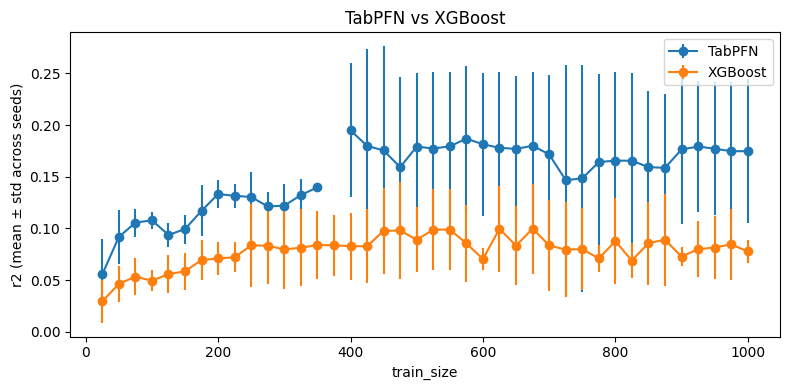

In [50]:
make_comparison_plot('r2')

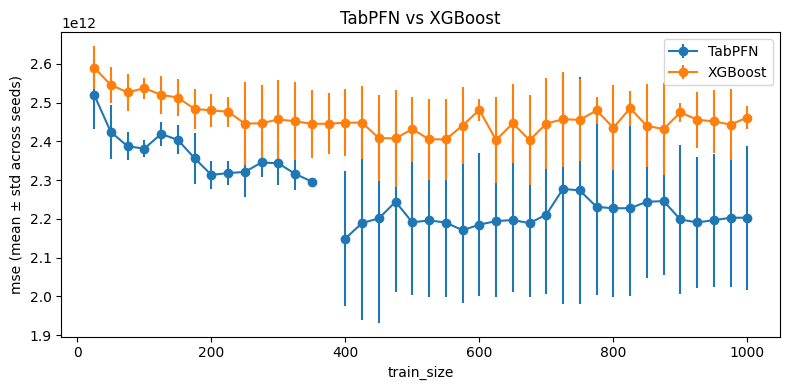

In [51]:
make_comparison_plot('mse')

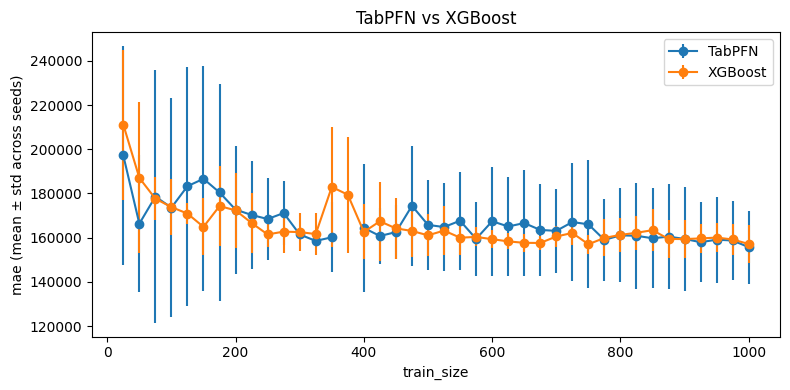

In [52]:
make_comparison_plot('mae')

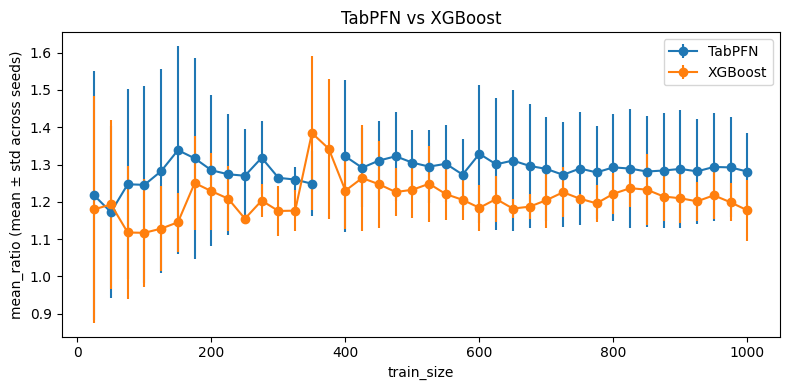

In [53]:
make_comparison_plot('mean_ratio')

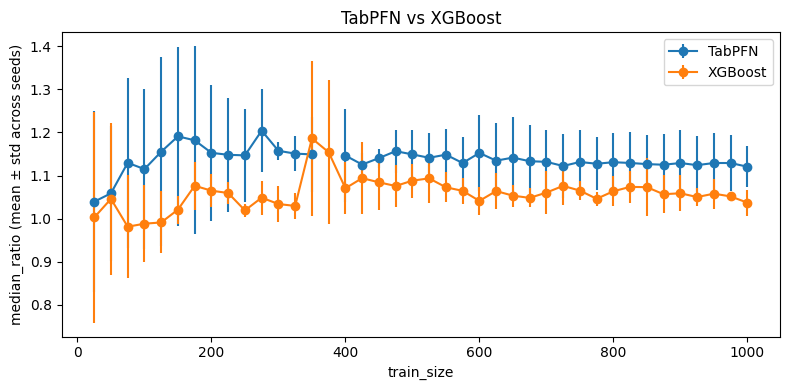

In [54]:
make_comparison_plot('median_ratio')

# TabPFN XGBoost 20 seeds train_sizes 100, 200, ..., 1000 comparison

In [2]:
tabpfn = pd.read_csv('../results/11_3_experiments/tabpfn_full.csv')
xgboost = pd.read_csv('../results/11_3_experiments/xgboost_full.csv')

In [3]:
tabpfn.head()

,seed,train_size,test_type,n_train,n_test,n_train_cbgs,n_test_cbgs,mae,mse,r2,mean_ratio,median_ratio,std_ratio,train_time,pred_time,status
0,0,100,full,100,10000,97,2869,134209.619829,1.458202e+12,0.141950,1.087028,1.002854,0.695852,5.144371,11.399575,success
1,0,200,full,200,10000,190,2869,129004.366352,1.477379e+12,0.130666,1.047615,0.963742,0.621078,0.987579,52.790778,success
2,0,300,full,300,10000,277,2869,128022.955726,1.439985e+12,0.152670,1.068061,0.991001,0.631120,1.656018,86.675312,success
3,0,400,full,400,10000,368,2869,136794.925410,1.394460e+12,0.179458,1.186563,1.067189,0.823745,1.545383,12.277909,success
4,0,500,full,500,10000,454,2869,155548.291314,1.333325e+12,0.215432,1.296699,1.174446,0.934326,1.741331,13.497015,success


In [7]:
comparison, cols_to_show = get_tabpfn_xgboost_comparison(tabpfn, xgboost)

In [10]:
comparison[cols_to_show][['tabpfn__r2_mean', 'xgboost__r2_mean']]

,tabpfn__r2_mean,xgboost__r2_mean
train_size,,
100,0.121580,0.071514
200,0.141014,-1.823477
300,0.139756,0.050298
400,0.141716,-0.009490
500,0.159976,0.002546
600,0.187804,-0.088546
700,0.177760,-0.459269
800,0.172150,-0.703935
900,0.168339,-0.382706


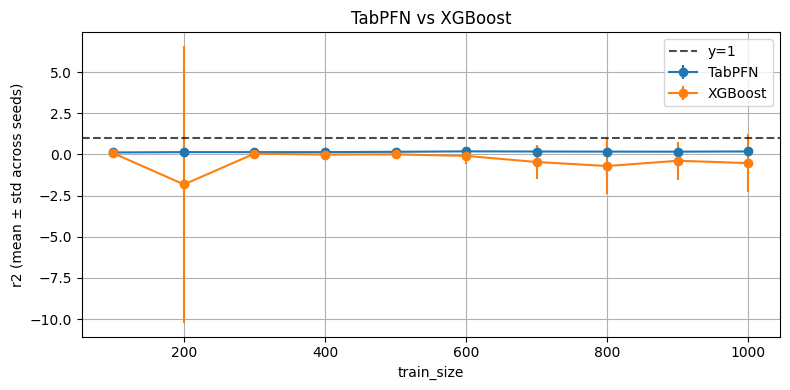

In [21]:
make_comparison_plot(comparison, 'r2', yline=1)

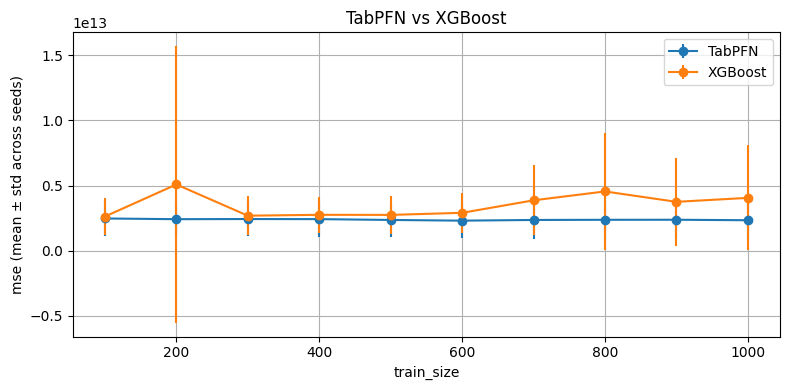

In [14]:
make_comparison_plot(comparison, 'mse')

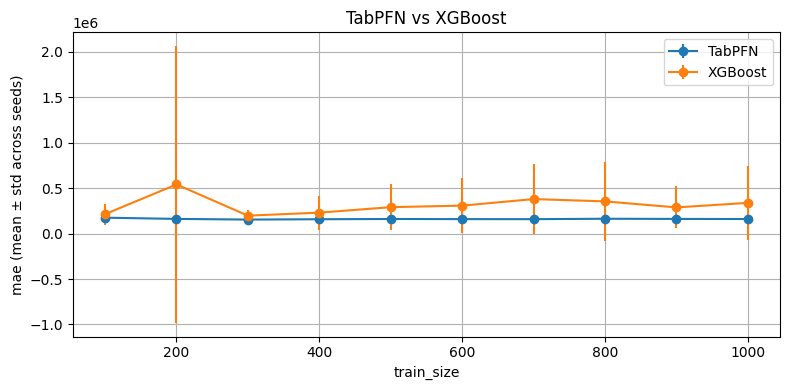

In [15]:
make_comparison_plot(comparison, 'mae')

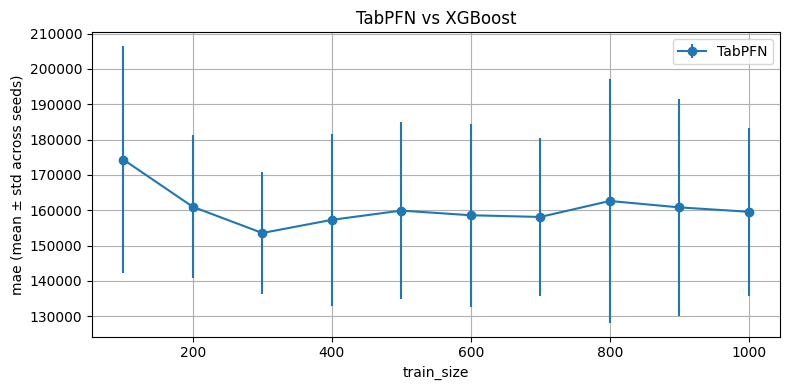

In [14]:
make_comparison_plot(comparison, 'mae', plot_xgboost_line=False)

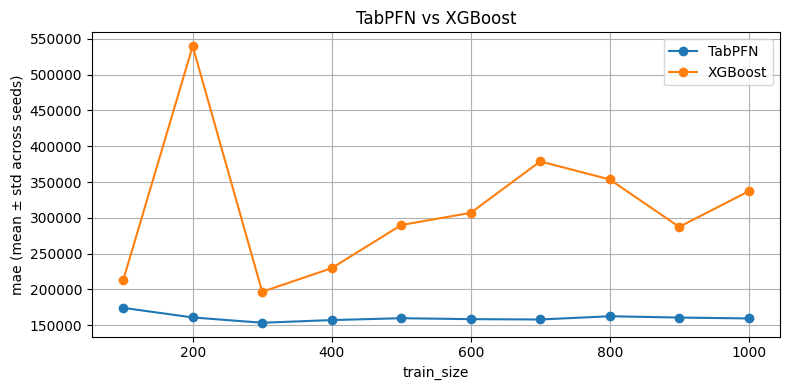

In [15]:
make_comparison_plot(comparison, 'mae', show_std=False)

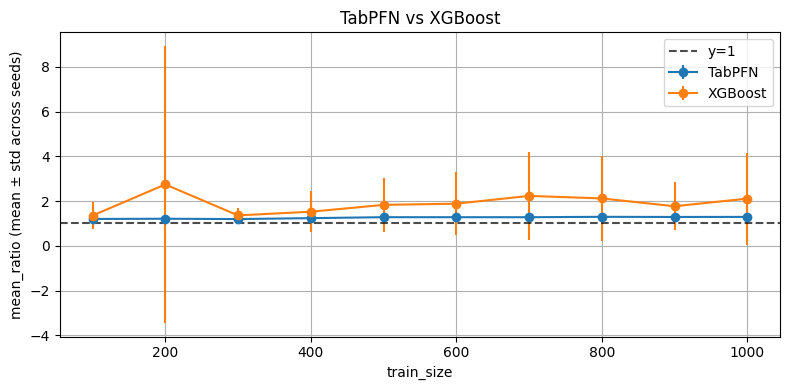

In [22]:
make_comparison_plot(comparison, 'mean_ratio', yline=1)

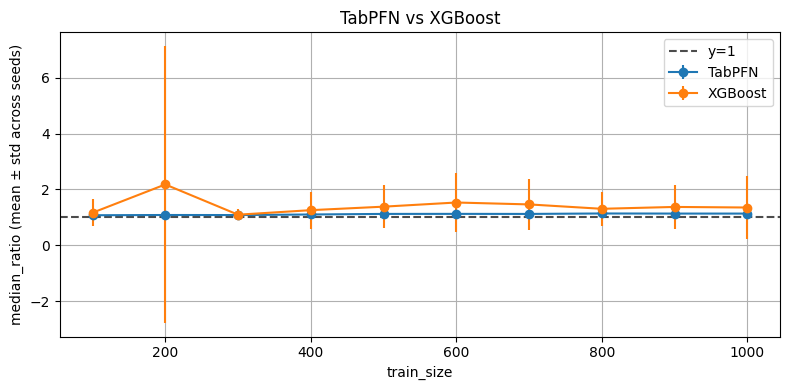

In [23]:
make_comparison_plot(comparison, 'median_ratio', yline=1)

# Seeds 1-20, train sizes 100, 200, ..., 1000, binned by sale value

In [3]:
df1 = pd.read_csv('results/predictions_by_bins_xgboost_aggregated.csv')
df2 = pd.read_csv('results/predictions_by_bins_tabpfn_aggregated.csv')
df3 = pd.read_csv('results/predictions_by_bins_comparison.csv')
df4 = pd.read_csv('results/predictions_by_bins_detailed.csv')

In [31]:
df1.head()

,model,bin,train_size,test_type,mae_mean,mae_std,mae_min,mae_max,mse_mean,mse_std,...,std_ratio_mean,std_ratio_std,std_ratio_min,std_ratio_max,mape_mean,mape_std,mape_min,mape_max,n_samples_first,n_seeds
0,xgboost,10M+,100,full,3.528112e+07,9.986776e+06,2.155165e+07,5.233449e+07,2.345780e+15,1.172231e+15,...,0.060364,0.076298,0.017885,0.293148,93.974453,4.525380,79.571533,97.395473,10,20
1,xgboost,10M+,200,full,3.454095e+07,1.032139e+07,2.145055e+07,5.177790e+07,2.293003e+15,1.186749e+15,...,0.083508,0.070513,0.011362,0.303741,90.326141,8.738769,60.745854,97.500954,10,20
2,xgboost,10M+,300,full,3.475519e+07,1.059621e+07,2.146567e+07,5.519430e+07,2.321155e+15,1.213603e+15,...,0.090238,0.097225,0.008033,0.374749,90.687019,7.964112,64.445630,97.254643,10,20
3,xgboost,10M+,400,full,3.487474e+07,1.022410e+07,2.155465e+07,5.301896e+07,2.320217e+15,1.187118e+15,...,0.111554,0.167077,0.009593,0.726576,91.922648,6.382773,77.243962,99.347511,10,20
4,xgboost,10M+,500,full,3.421129e+07,9.912987e+06,2.168421e+07,5.233663e+07,2.226589e+15,1.171820e+15,...,0.203481,0.359871,0.012061,1.645624,91.115056,11.533452,71.700470,126.961666,10,20


In [32]:
df2.head()

,model,bin,train_size,test_type,mae_mean,mae_std,mae_min,mae_max,mse_mean,mse_std,...,std_ratio_mean,std_ratio_std,std_ratio_min,std_ratio_max,mape_mean,mape_std,mape_min,mape_max,n_samples_first,n_seeds
0,tabpfn,10M+,100,full,3.400953e+07,9.916999e+06,1.937545e+07,5.124556e+07,2.208295e+15,1.116914e+15,...,0.123715,0.086251,0.020805,0.378925,89.315289,5.341901,74.779082,97.186783,10,20
1,tabpfn,10M+,200,full,3.376632e+07,1.001002e+07,2.055241e+07,5.150957e+07,2.176370e+15,1.101493e+15,...,0.172334,0.183313,0.020154,0.716496,88.678222,6.619968,74.600520,96.703519,10,20
2,tabpfn,10M+,300,full,3.392249e+07,9.993508e+06,2.027118e+07,5.146152e+07,2.198665e+15,1.108763e+15,...,0.136859,0.133085,0.020901,0.469843,89.032721,7.910075,67.890401,96.650803,10,20
3,tabpfn,10M+,400,full,3.372097e+07,9.873239e+06,2.201855e+07,5.179836e+07,2.173987e+15,1.114037e+15,...,0.188869,0.187174,0.012064,0.801716,88.110094,7.044517,71.011307,95.827826,10,20
4,tabpfn,10M+,500,full,3.336989e+07,9.712156e+06,2.166266e+07,5.048016e+07,2.102954e+15,1.100002e+15,...,0.312981,0.517520,0.014752,2.318134,90.338515,15.238872,72.022320,146.596421,10,20


In [33]:
df3.head()

,model_tabpfn,bin,train_size,test_type,mae_mean_tabpfn,mae_std_tabpfn,mae_min_tabpfn,mae_max_tabpfn,mse_mean_tabpfn,mse_std_tabpfn,...,n_samples_first_xgboost,n_seeds_xgboost,delta_mae,delta_mse,delta_rmse,delta_r2,delta_mean_ratio,delta_median_ratio,delta_std_ratio,delta_mape
0,tabpfn,10M+,100,full,3.400953e+07,9.916999e+06,1.937545e+07,5.124556e+07,2.208295e+15,1.116914e+15,...,10,20,-1.271590e+06,-1.374848e+14,-1.431698e+06,0.140762,0.049266,0.024467,0.063351,-4.659164
1,tabpfn,10M+,200,full,3.376632e+07,1.001002e+07,2.055241e+07,5.150957e+07,2.176370e+15,1.101493e+15,...,10,20,-7.746325e+05,-1.166321e+14,-1.122246e+06,0.087447,0.045213,-0.005767,0.088826,-1.647919
2,tabpfn,10M+,300,full,3.392249e+07,9.993508e+06,2.027118e+07,5.146152e+07,2.198665e+15,1.108763e+15,...,10,20,-8.327040e+05,-1.224892e+14,-1.175853e+06,0.102895,0.023998,0.003357,0.046622,-1.654298
3,tabpfn,10M+,400,full,3.372097e+07,9.873239e+06,2.201855e+07,5.179836e+07,2.173987e+15,1.114037e+15,...,10,20,-1.153773e+06,-1.462297e+14,-1.470653e+06,0.122317,0.054006,0.013369,0.077315,-3.812553
4,tabpfn,10M+,500,full,3.336989e+07,9.712156e+06,2.166266e+07,5.048016e+07,2.102954e+15,1.100002e+15,...,10,20,-8.414016e+05,-1.236342e+14,-1.286100e+06,0.117267,0.064297,0.017818,0.109500,-0.776541


In [17]:
df1.shape, df2.shape, df3.shape, df4.shape

((60, 38), (60, 38), (60, 81), (2400, 14))

In [15]:
df4.head()

,model,bin,train_size,seed,test_type,mae,mse,rmse,r2,mean_ratio,median_ratio,std_ratio,mape,n_samples
0,tabpfn,<200k,100,0,full,57043.727192,7.027587e+09,83830.704915,-2.337202,1.529174,1.273910,1.356441,60.033228,2036
1,tabpfn,<200k,100,1,full,177854.182389,4.206183e+10,205089.819522,-18.915909,2.783551,2.155205,2.257475,178.355126,2024
2,tabpfn,<200k,100,2,full,60295.723703,7.003206e+09,83685.157694,-2.520652,1.543450,1.319371,1.921121,61.949905,2033
3,tabpfn,<200k,100,3,full,72195.121770,9.781182e+09,98899.857369,-3.935594,1.712100,1.424657,2.482535,75.349180,2075
4,tabpfn,<200k,100,4,full,74355.903187,1.393027e+10,118026.571495,-5.892818,1.614783,1.367931,1.036866,69.614849,2048


In [67]:
def plot_metric_by_train_size_and_bin(df1, df2, metric='mae', bins=None, figsize=None, r2_ylow=None, r2_yhigh=None):
    """
    Plot metric (mean ± std) vs train_size with one subplot per bin.
    Each subplot shows both models (TabPFN and XGBoost).
    
    Parameters:
    -----------
    df1 : DataFrame
        XGBoost aggregated results (from predictions_by_bins_xgboost_aggregated.csv)
    df2 : DataFrame
        TabPFN aggregated results (from predictions_by_bins_tabpfn_aggregated.csv)
    metric : str
        Metric to plot (e.g., 'mae', 'mse', 'r2', 'mean_ratio', 'median_ratio', 'std_ratio')
    bins : list, str, or None
        Which bins to show. If None, show all bins. If list, show only those bins.
        If string, show only that bin.
    figsize : tuple
        Figure size (width, height). If None, automatically calculated based on number of bins.
    """
    # Combine both dataframes
    df_combined = pd.concat([df1, df2], ignore_index=True)
    
    # Get unique bins and models
    all_bins = sorted(df_combined['bin'].unique())
    models = sorted(df_combined['model'].unique())
    
    # Filter bins if specified
    if bins is None:
        bins = all_bins
    elif isinstance(bins, str):
        bins = [bins]
    else:
        # Ensure bins is a list
        bins = list(bins)
    
    # Validate that requested bins exist
    available_bins = [b for b in bins if b in all_bins]
    missing_bins = [b for b in bins if b not in all_bins]
    
    if missing_bins:
        print(f"Warning: The following bins were not found in the data: {missing_bins}")
        print(f"Available bins: {all_bins}")
    
    if not available_bins:
        print("Error: No valid bins to plot. Please check your bin selection.")
        return None, None
    
    bins = sorted(available_bins)
    n_bins = len(bins)
    
    # Calculate subplot grid layout
    # Aim for roughly 2 columns, adjust rows as needed
    n_cols = min(2, n_bins)
    n_rows = (n_bins + n_cols - 1) // n_cols  # Ceiling division
    
    # Set default figsize if not provided
    if figsize is None:
        # Width per subplot: 6, Height per subplot: 4
        figsize = (n_cols * 6, n_rows * 4)
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, sharey=False)
    
    # Handle case where there's only one subplot
    if n_bins == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if isinstance(axes, list) else [axes]
    else:
        axes = axes.flatten()
    
    # Get train sizes
    train_sizes = sorted(df_combined['train_size'].unique())
    
    # Plot each bin in its own subplot
    for bin_idx, bin_val in enumerate(bins):
        ax = axes[bin_idx]
        
        # Plot both models for this bin
        for model in models:
            # Filter data for this bin and model
            data_subset = df_combined[
                (df_combined['bin'] == bin_val) & 
                (df_combined['model'] == model)
            ].sort_values('train_size')
            
            if len(data_subset) == 0:
                continue
            
            # Get mean and std values
            mean_col = f'{metric}_mean'
            std_col = f'{metric}_std'
            
            if mean_col not in data_subset.columns or std_col not in data_subset.columns:
                print(f"Warning: {mean_col} or {std_col} not found in data")
                continue
            
            # Get train sizes and metric values
            x = data_subset['train_size'].values
            y_mean = data_subset[mean_col].values
            y_std = data_subset[std_col].values
            
            # Create label
            label = model
            
            # Make error bars visually distinct for different models
            # TabPFN: smaller caps, thinner error bar lines
            # XGBoost: larger caps, thicker error bar lines
            if model == 'tabpfn':
                capsize = 4
                capthick = 1.5
                elinewidth = 1.5
                linestyle = '-'
                marker_size = 7
                color = 'blue'
            else:  # xgboost
                capsize = 6
                capthick = 2.5
                elinewidth = 2.5
                linestyle = '--'
                marker_size = 6
                color = 'red'
            
            # Plot with error bars
            ax.errorbar(
                x, y_mean, yerr=y_std,
                label=label,
                marker='o',
                markersize=marker_size,
                capsize=capsize,
                capthick=capthick,
                elinewidth=elinewidth,  # Error bar line width
                linestyle=linestyle,
                linewidth=2.0,
                color=color,
                alpha=0.85,
                markeredgewidth=1.5,
                markeredgecolor='white',
                markerfacecolor=color
            )
        
        # Set labels and title for this subplot
        ax.set_xlabel('Train Size', fontsize=11)
        ax.set_ylabel(f'{metric} (mean ± std)', fontsize=11)
        ax.set_title(f'{bin_val}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9)

        if metric == 'r2' and r2_ylow is not None and r2_yhigh is not None:
            ax.set_ylim(r2_ylow, r2_yhigh)
    
    # Hide unused subplots
    for idx in range(n_bins, len(axes)):
        axes[idx].set_visible(False)
    
    # Add overall title
    fig.suptitle(f'{metric.upper()} by Train Size (by bin)', fontsize=14, fontweight='bold', y=1.0)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle
    plt.show()
    
    return fig, axes


In [11]:
df1['bin'].unique()

array(['10M+', '1M-2M', '200k-500k', '2M-10M', '500k-1M', '<200k'],
      dtype=object)

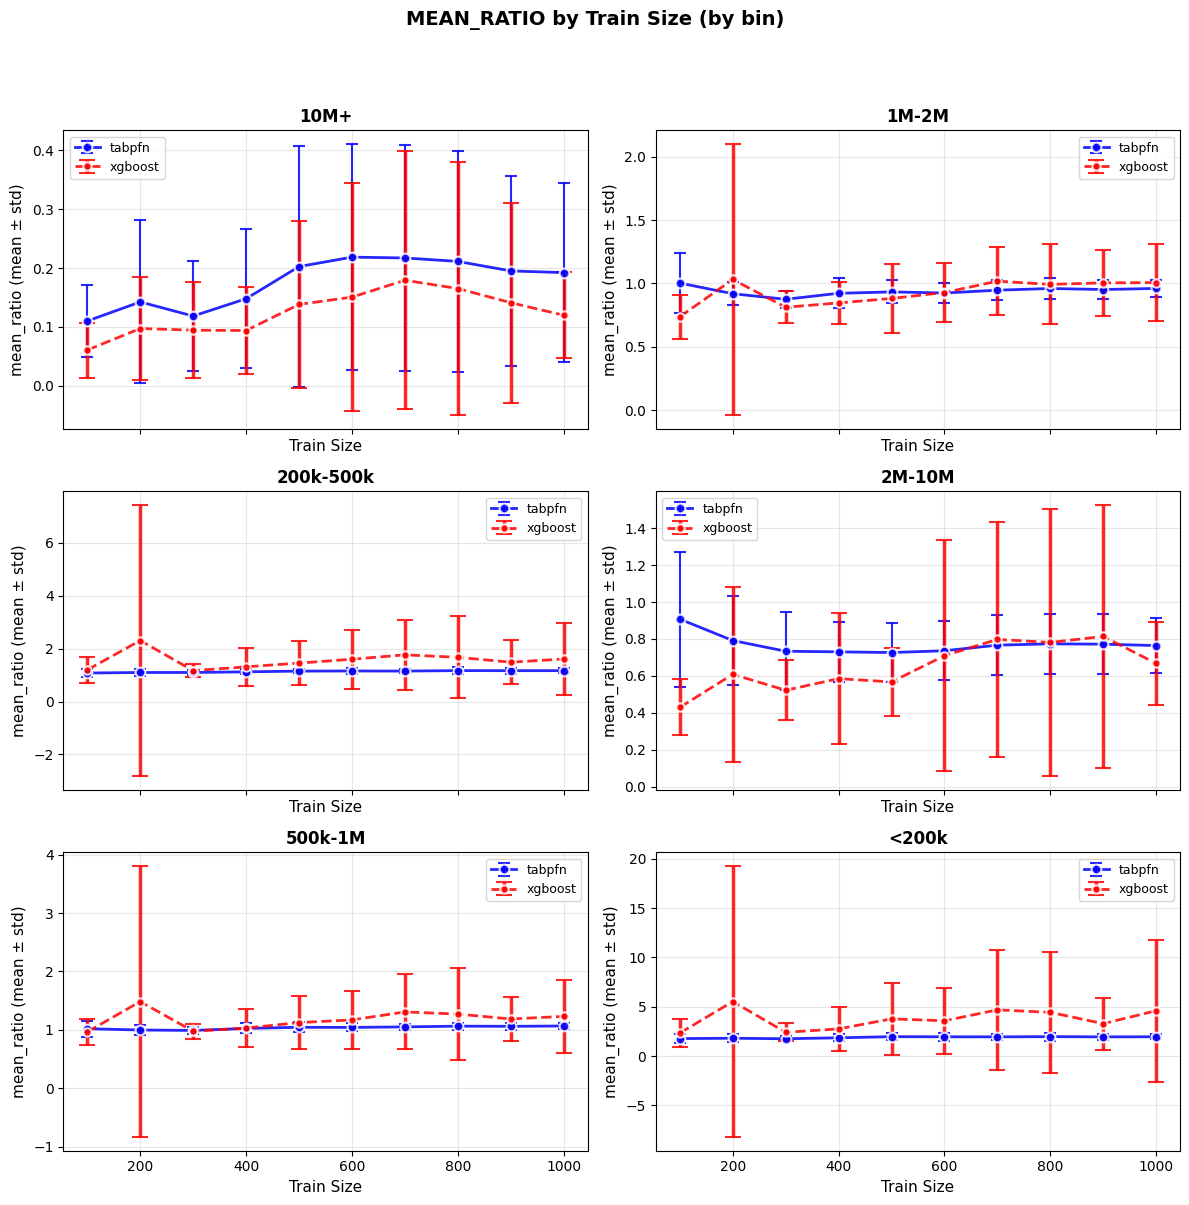

(<Figure size 1200x1200 with 6 Axes>,
 array([<Axes: title={'center': '10M+'}, xlabel='Train Size', ylabel='mean_ratio (mean ± std)'>,
        <Axes: title={'center': '1M-2M'}, xlabel='Train Size', ylabel='mean_ratio (mean ± std)'>,
        <Axes: title={'center': '200k-500k'}, xlabel='Train Size', ylabel='mean_ratio (mean ± std)'>,
        <Axes: title={'center': '2M-10M'}, xlabel='Train Size', ylabel='mean_ratio (mean ± std)'>,
        <Axes: title={'center': '500k-1M'}, xlabel='Train Size', ylabel='mean_ratio (mean ± std)'>,
        <Axes: title={'center': '<200k'}, xlabel='Train Size', ylabel='mean_ratio (mean ± std)'>],
       dtype=object))

In [34]:
plot_metric_by_train_size_and_bin(df1, df2, metric='mean_ratio',
 bins=['<200k', '200k-500k', '500k-1M', '1M-2M', '2M-10M', '10M+'])

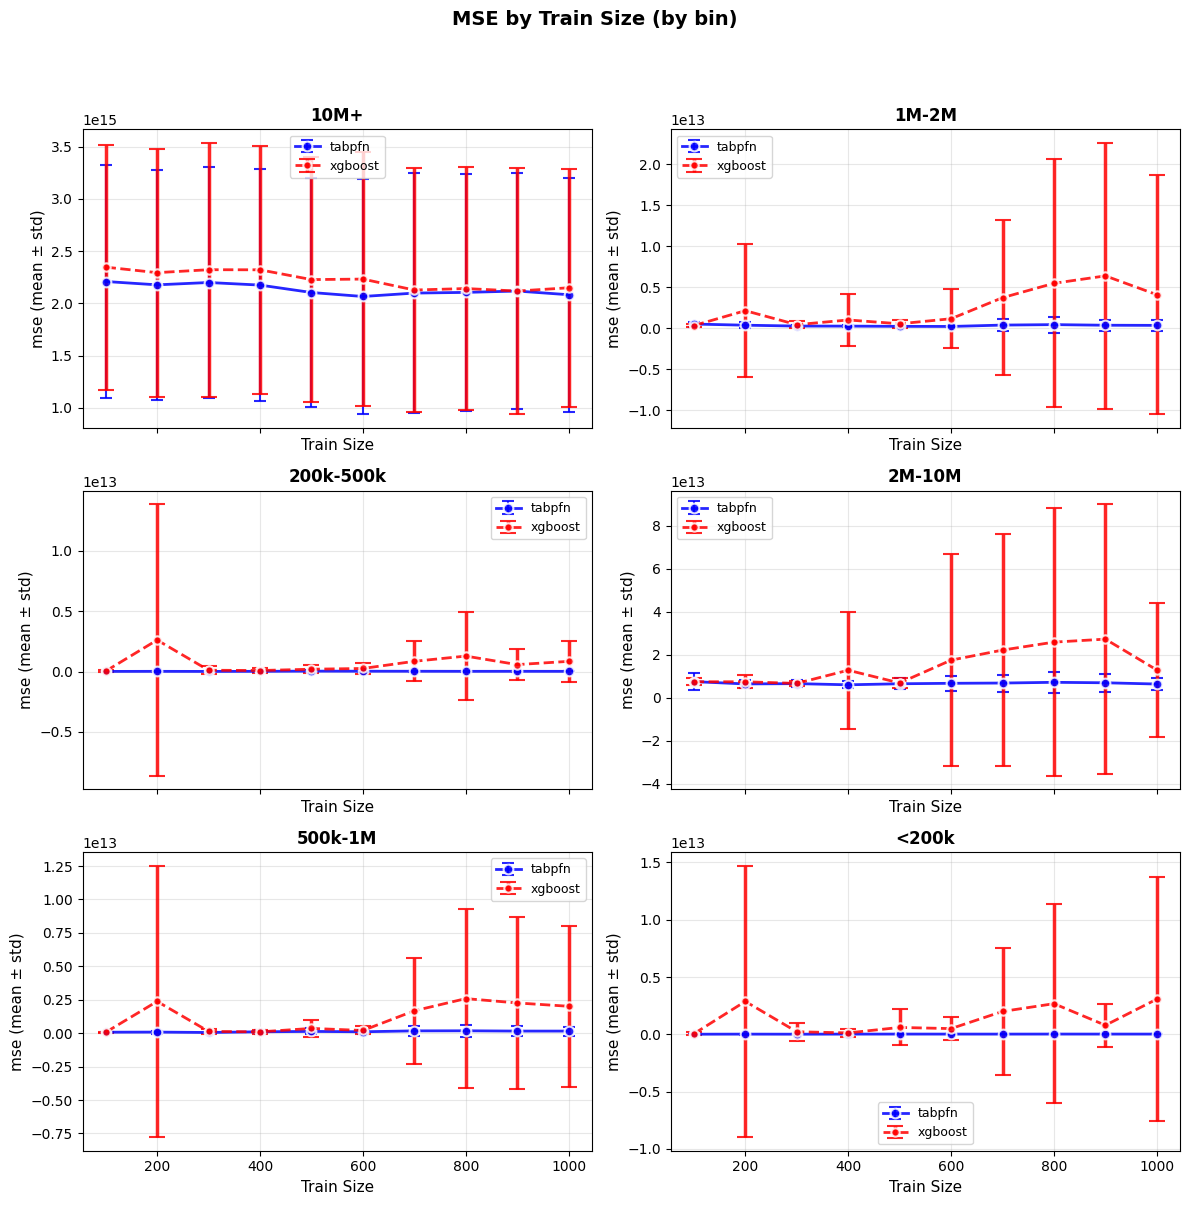

(<Figure size 1200x1200 with 6 Axes>,
 array([<Axes: title={'center': '10M+'}, xlabel='Train Size', ylabel='mse (mean ± std)'>,
        <Axes: title={'center': '1M-2M'}, xlabel='Train Size', ylabel='mse (mean ± std)'>,
        <Axes: title={'center': '200k-500k'}, xlabel='Train Size', ylabel='mse (mean ± std)'>,
        <Axes: title={'center': '2M-10M'}, xlabel='Train Size', ylabel='mse (mean ± std)'>,
        <Axes: title={'center': '500k-1M'}, xlabel='Train Size', ylabel='mse (mean ± std)'>,
        <Axes: title={'center': '<200k'}, xlabel='Train Size', ylabel='mse (mean ± std)'>],
       dtype=object))

In [36]:
plot_metric_by_train_size_and_bin(df1, df2, metric='mse')#, bins=['<200k'])

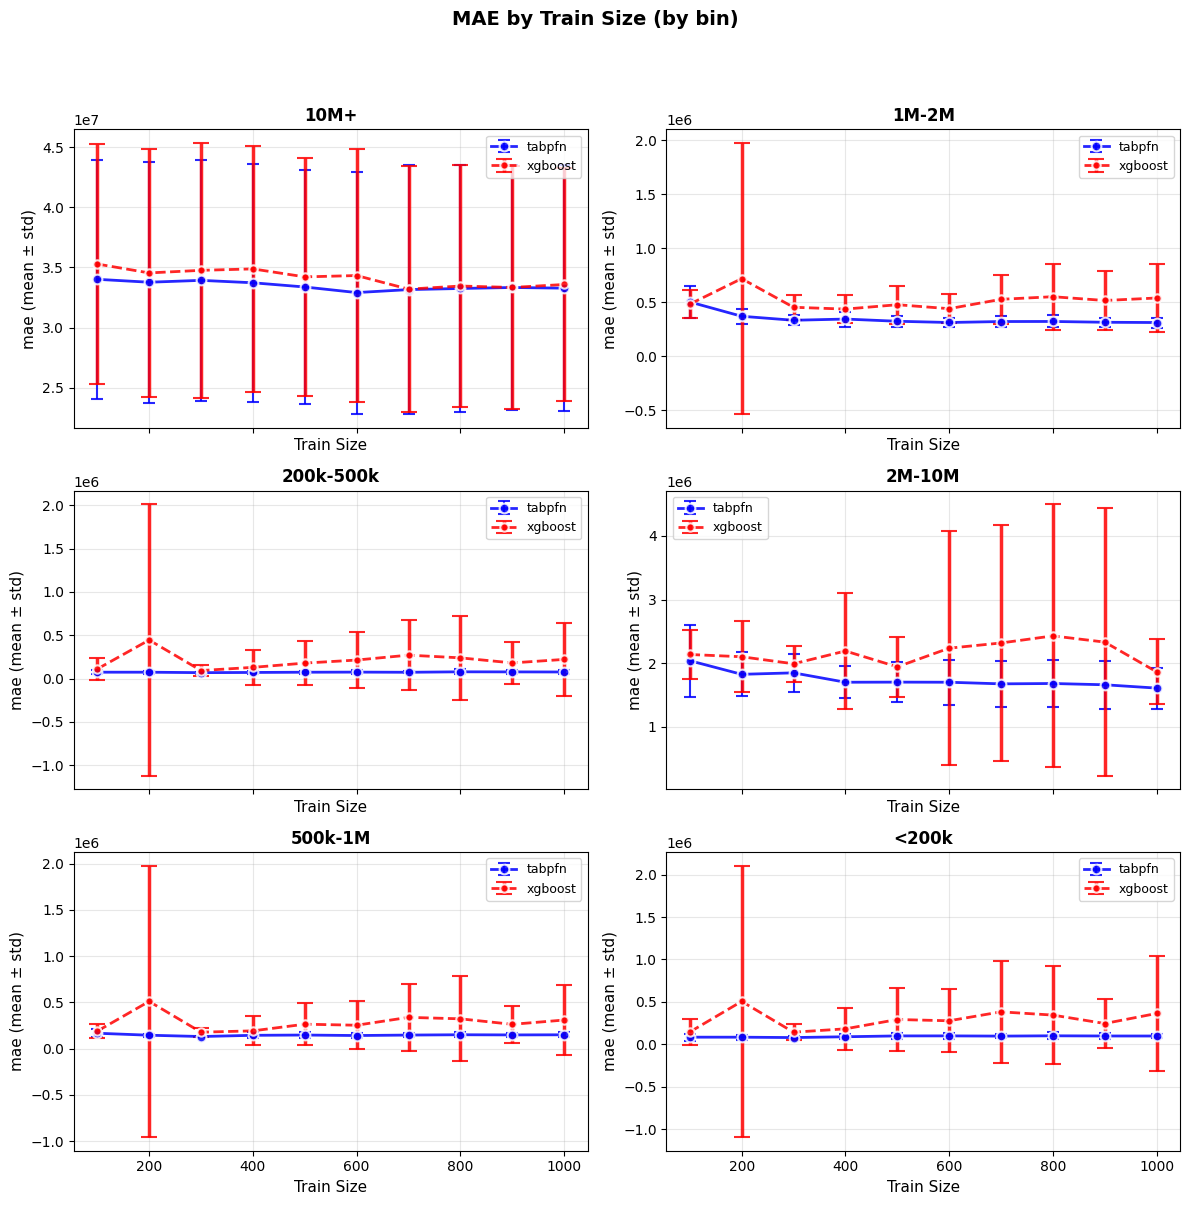

(<Figure size 1200x1200 with 6 Axes>,
 array([<Axes: title={'center': '10M+'}, xlabel='Train Size', ylabel='mae (mean ± std)'>,
        <Axes: title={'center': '1M-2M'}, xlabel='Train Size', ylabel='mae (mean ± std)'>,
        <Axes: title={'center': '200k-500k'}, xlabel='Train Size', ylabel='mae (mean ± std)'>,
        <Axes: title={'center': '2M-10M'}, xlabel='Train Size', ylabel='mae (mean ± std)'>,
        <Axes: title={'center': '500k-1M'}, xlabel='Train Size', ylabel='mae (mean ± std)'>,
        <Axes: title={'center': '<200k'}, xlabel='Train Size', ylabel='mae (mean ± std)'>],
       dtype=object))

In [37]:
plot_metric_by_train_size_and_bin(df1, df2, metric='mae')

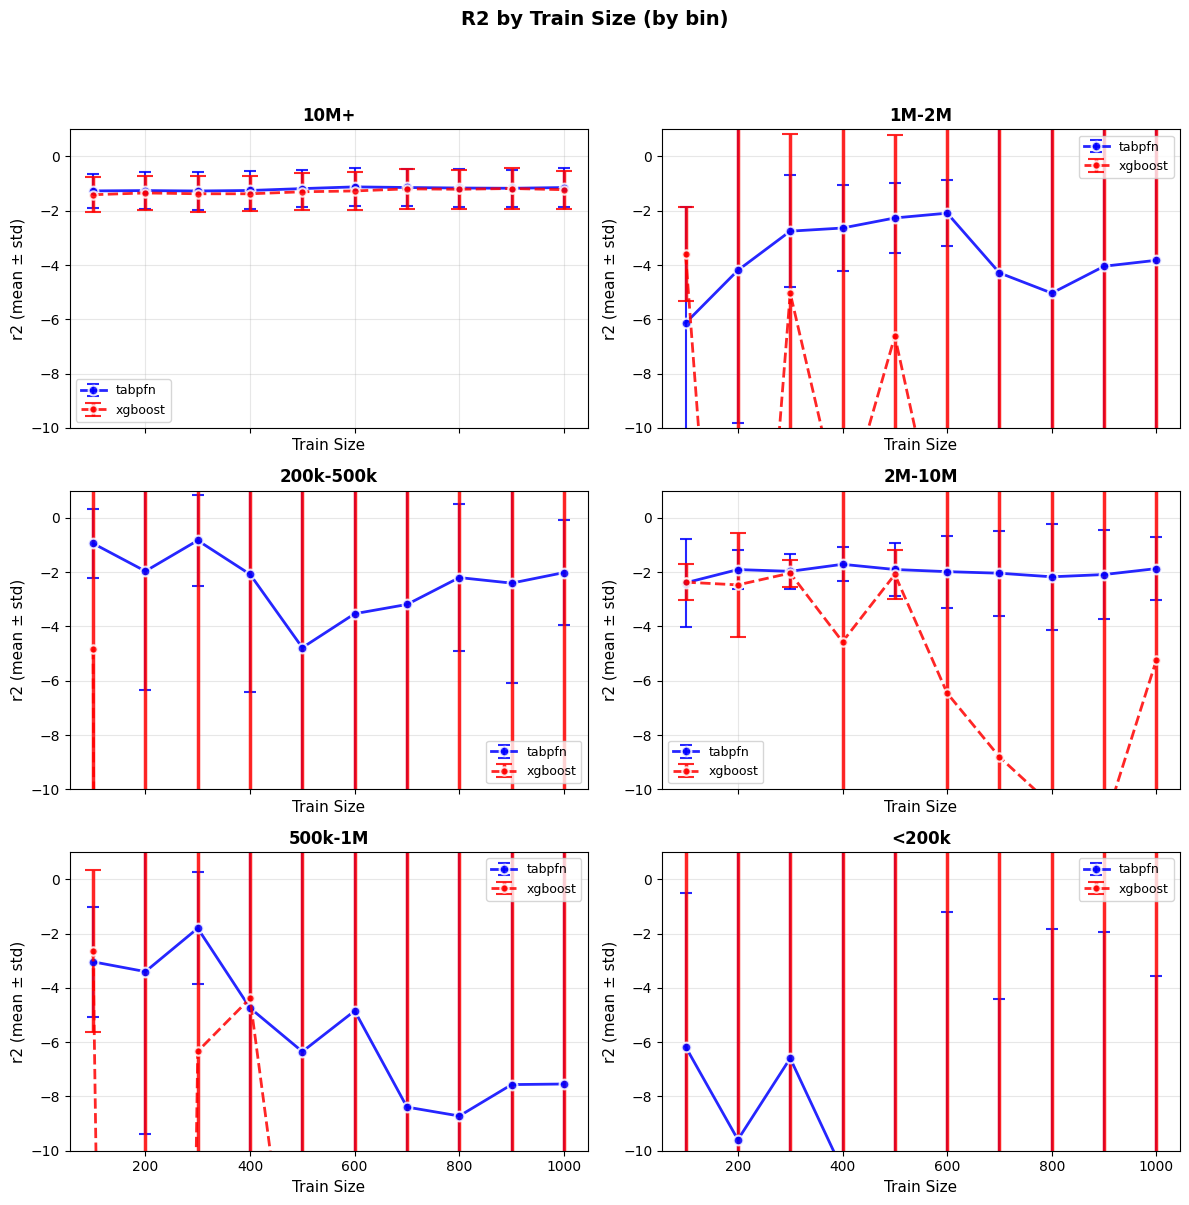

(<Figure size 1200x1200 with 6 Axes>,
 array([<Axes: title={'center': '10M+'}, xlabel='Train Size', ylabel='r2 (mean ± std)'>,
        <Axes: title={'center': '1M-2M'}, xlabel='Train Size', ylabel='r2 (mean ± std)'>,
        <Axes: title={'center': '200k-500k'}, xlabel='Train Size', ylabel='r2 (mean ± std)'>,
        <Axes: title={'center': '2M-10M'}, xlabel='Train Size', ylabel='r2 (mean ± std)'>,
        <Axes: title={'center': '500k-1M'}, xlabel='Train Size', ylabel='r2 (mean ± std)'>,
        <Axes: title={'center': '<200k'}, xlabel='Train Size', ylabel='r2 (mean ± std)'>],
       dtype=object))

In [72]:
plot_metric_by_train_size_and_bin(df1, df2, metric='r2', r2_ylow=-10, r2_yhigh=1)

In [19]:
test = pd.read_parquet('/nlp/scr/salilg/cook_county_predictions/tabpfn/seed0_size100_full.parquet')

In [53]:
test2 = test[(test['y_true'] < 200000) & (test['y_pred'] < 0.8e6)]

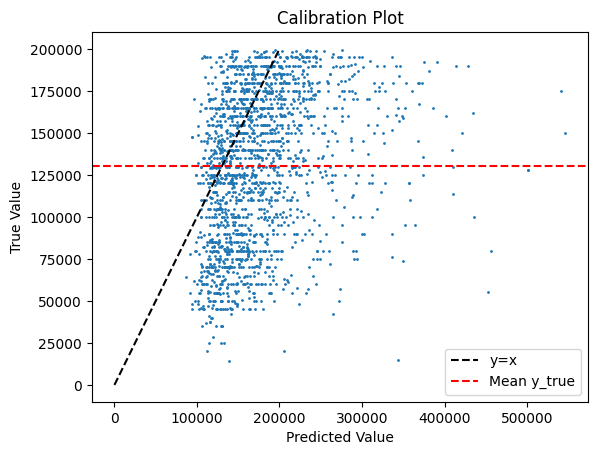

In [70]:
plt.scatter(test2['y_pred'], test2['y_true'],  s=1)

# draw a line y=x
plt.plot([0, 200000], [0, 200000], 'k--', label='y=x')

# plot the mean y_true on the y-axis
plt.axhline(test2['y_true'].mean(), color='r', linestyle='--', label='Mean y_true')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.title('Calibration Plot')
plt.legend()
plt.show()


In [55]:
# MSE in test2
mse_test2 = ((test2['y_true'] - test2['y_pred']) ** 2).mean()
mse_test2

np.float64(5861627843.777132)

In [56]:
# MSE from predicting the mean y_true
mse_mean = ((test2['y_true'] - test2['y_true'].mean()) ** 2).mean()
mse_mean


np.float64(1952585684.444285)

In [57]:
from sklearn.metrics import r2_score
r2_score(test2['y_true'], test2['y_pred'])


-2.001982392104538

Yikes! $R^2$ being negative means both the models are doing worse than a dummy model that always predicts the mean `y_true`. Let's re-run experiment with dropping some definitively spurious columns like ID columns.

# Seeds 1-20, train size 1k, spurious columns dropped from data

In [4]:
from sklearn.metrics import r2_score

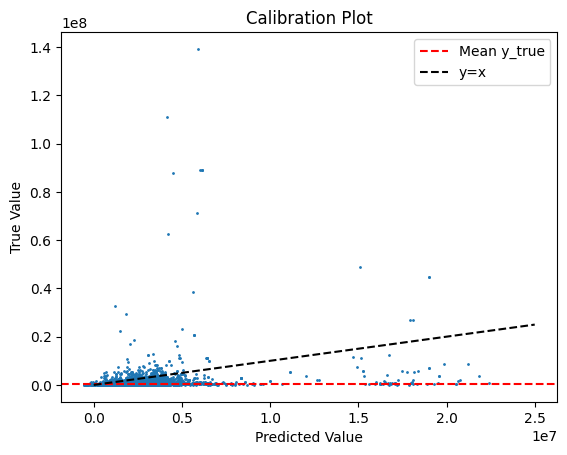

-1.0478788172631575


In [16]:
test = pd.read_parquet('/nlp/scr/salilg/cook_county_predictions/xgboost-1k-train-dropped-columns/xgboost/xgboost/seed4_size1000_full.parquet')

plt.scatter(test['y_pred'], test['y_true'], s=1)
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.axhline(test['y_true'].mean(), color='r', linestyle='--', label='Mean y_true')

#y=x line
plt.plot([0, 2.5e7], [0, 2.5e7], 'k--', label='y=x')

plt.title('Calibration Plot')
plt.legend()
plt.show()
print(r2_score(test['y_true'], test['y_pred']))


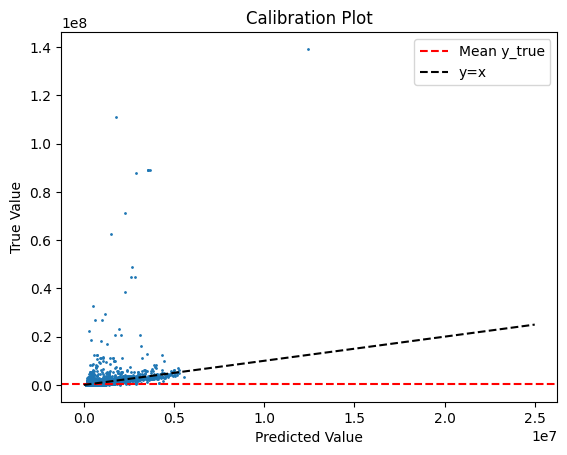

0.13162492880333165


In [5]:
test = pd.read_parquet('/nlp/scr/salilg/cook_county_predictions/1k-train-dropped-columns/tabpfn/seed4_size1000_full.parquet')

plt.scatter(test['y_pred'], test['y_true'], s=1)
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.axhline(test['y_true'].mean(), color='r', linestyle='--', label='Mean y_true')

#y=x line
plt.plot([0, 2.5e7], [0, 2.5e7], 'k--', label='y=x')

plt.title('Calibration Plot')
plt.legend()
plt.show()
print(r2_score(test['y_true'], test['y_pred']))


-10.235548610781773


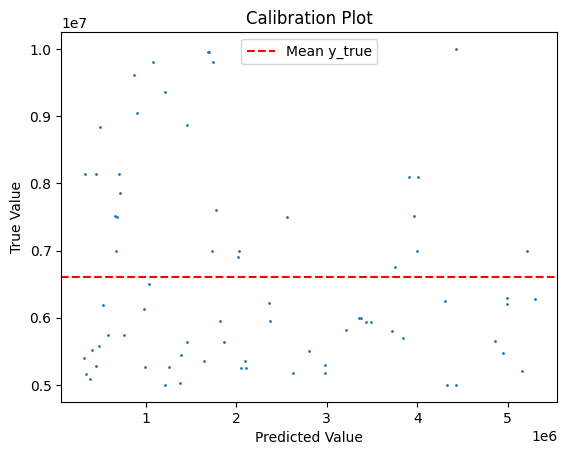

In [24]:
test2 = test[(test['y_true'] >= 5000000) & (test['y_true'] <= 10000000)]
print(r2_score(test2['y_true'], test2['y_pred']))

plt.scatter(test2['y_pred'], test2['y_true'], s=1)
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.axhline(test2['y_true'].mean(), color='r', linestyle='--', label='Mean y_true')
# plt.plot([0, 2.5e7], [0, 2.5e7], 'k--', label='y=x')
plt.title('Calibration Plot')
plt.legend()

In [27]:
import os
os.listdir('../results/1k-train-dropped-columns/by_bins')

['predictions_by_bins_xgboost_aggregated.csv',
 'predictions_by_bins_detailed.csv',
 'predictions_by_bins_tabpfn_aggregated.csv',
 'predictions_by_bins_comparison.csv']

In [35]:
bybin = pd.read_csv('../results/1k-train-dropped-columns/by_bins/predictions_by_bins_detailed.csv')
bybin# ['r2_mean']

,model,bin,train_size,seed,test_type,mae,mse,rmse,r2,mean_ratio,median_ratio,std_ratio,mape,n_samples
0,tabpfn,<200k,1000,0,full,8.650433e+04,1.459291e+10,1.208011e+05,-6.144344,1.828749,1.524382,1.805855,85.810508,8007
1,tabpfn,<200k,1000,1,full,6.734431e+04,8.825196e+09,9.394251e+04,-3.320606,1.598086,1.364928,1.997214,66.623118,8007
2,tabpfn,<200k,1000,2,full,1.459515e+05,5.944859e+10,2.438208e+05,-28.104621,2.456982,1.894264,3.292895,145.816000,8007
3,tabpfn,<200k,1000,3,full,8.527545e+04,2.328847e+10,1.526056e+05,-10.401485,1.777974,1.408388,2.194092,84.666394,8007
4,tabpfn,<200k,1000,4,full,1.047785e+05,1.921255e+10,1.386094e+05,-8.406010,2.050201,1.681651,2.467992,105.583627,8007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,xgboost,10M+,1000,15,full,3.498100e+07,1.910823e+15,4.371297e+07,-0.774982,0.723888,0.050166,1.583874,122.199043,41
236,xgboost,10M+,1000,16,full,2.933631e+07,1.687046e+15,4.107367e+07,-0.567113,0.212298,0.092544,0.220459,78.770198,41
237,xgboost,10M+,1000,17,full,3.231266e+07,2.056713e+15,4.535100e+07,-0.910500,0.158676,0.076483,0.173567,84.132372,41
238,xgboost,10M+,1000,18,full,3.492643e+07,2.287837e+15,4.783134e+07,-1.125194,0.046436,0.031966,0.038241,95.356397,41


In [36]:
(bybin[bybin['r2'] > 0])

,model,bin,train_size,seed,test_type,mae,mse,rmse,r2,mean_ratio,median_ratio,std_ratio,mape,n_samples
151,xgboost,200k-500k,1000,11,full,52421.438444,5.171216e+09,71911.164009,0.140728,0.997677,0.969222,0.228944,16.529669,22536


# Seeds 1-20, train size 1k, only column = `CALCULATED_TOTAL_VALUE`

In [17]:
df1 = pd.read_csv('../results/1k-train-only-calculated-sale-amount/tabpfn.csv')
df2 = pd.read_csv('../results/1k-train-only-calculated-sale-amount/xgboost.csv')

In [18]:
comparison, cols_to_show = get_tabpfn_xgboost_comparison(df1, df2)

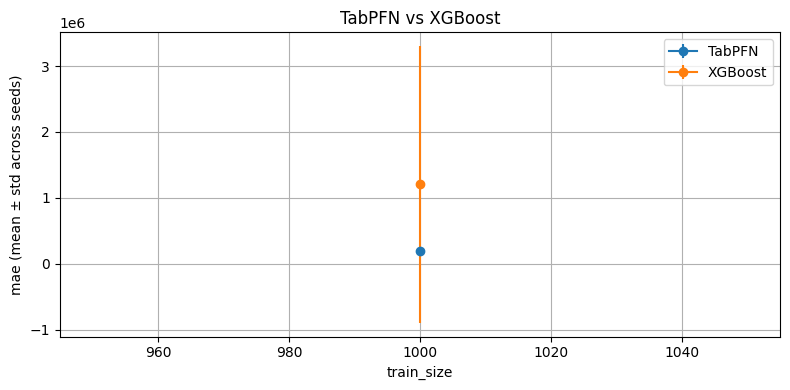

In [19]:
make_comparison_plot(comparison, 'mae')

## binned

In [41]:
bybin = pd.read_csv('../results/1k-train-only-calculated-sale-amount/by_bins/predictions_by_bins_detailed.csv')

In [42]:
bybin

,model,bin,train_size,seed,test_type,mae,mse,rmse,r2,mean_ratio,median_ratio,std_ratio,mape,n_samples
0,tabpfn,<200k,1000,0,full,1.131233e+05,1.700843e+10,1.304164e+05,-7.326924,2.126895,1.770000,1.848362,112.754620,8007
1,tabpfn,<200k,1000,1,full,8.977335e+04,1.134976e+10,1.065352e+05,-4.556572,1.921529,1.600988,1.605254,92.277327,8007
2,tabpfn,<200k,1000,2,full,1.707493e+05,3.325811e+10,1.823681e+05,-15.282384,2.680189,2.150828,2.226621,168.018912,8007
3,tabpfn,<200k,1000,3,full,1.313375e+05,2.108103e+10,1.451931e+05,-9.320770,2.297897,1.894373,1.995816,129.789714,8007
4,tabpfn,<200k,1000,4,full,1.995815e+05,4.633620e+10,2.152584e+05,-21.685103,2.876813,2.371152,2.114743,187.681345,8007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,xgboost,10M+,1000,15,full,3.233656e+07,2.023288e+15,4.498097e+07,-0.879451,0.327328,0.113196,0.704715,87.430030,41
236,xgboost,10M+,1000,16,full,3.401153e+07,2.170686e+15,4.659062e+07,-1.016371,0.065537,0.036127,0.095334,93.446270,41
237,xgboost,10M+,1000,17,full,3.395214e+07,2.259983e+15,4.753928e+07,-1.099320,0.124061,0.023546,0.282227,88.394149,41
238,xgboost,10M+,1000,18,full,3.489741e+07,2.285114e+15,4.780286e+07,-1.122664,0.047518,0.030856,0.039846,95.248221,41


In [6]:
test = pd.read_parquet('/nlp/scr/salilg/cook_county_predictions/1k-train-only-calculated-sale-amount/tabpfn/seed0_size1000.parquet')

In [65]:
def make_calibration_plot(test):
    plt.scatter(test['y_true'], test['y_pred'], s=1)
    plt.xlabel('True Value')
    plt.ylabel('Predicted Value')
    plt.axhline(test['y_true'].mean(), color='r', linestyle='--', label='Mean y_true')

    #y=x line
    max_true_val = test['y_true'].max()
    plt.plot([0, max_true_val], [0, max_true_val], 'k--', label='y=x')

    # add annotation with r2 score on plot
    r2 = r2_score(test['y_true'], test['y_pred'])
    plt.annotate(f'R^2 = {r2:.2f}', xy=(0.8, 0.05), xycoords='axes fraction', fontsize=8)
    plt.annotate(f'corr = {test["y_true"].corr(test["y_pred"]):.2f}', xy=(0.8, 0.1), xycoords='axes fraction', fontsize=8)

    plt.xlim(test['y_true'].min(), test['y_true'].max())

    plt.title('Calibration Plot')
    plt.legend()
    plt.show()
    

In [37]:
test['y_true'].corr(test['y_pred'])

np.float64(0.514013899824782)

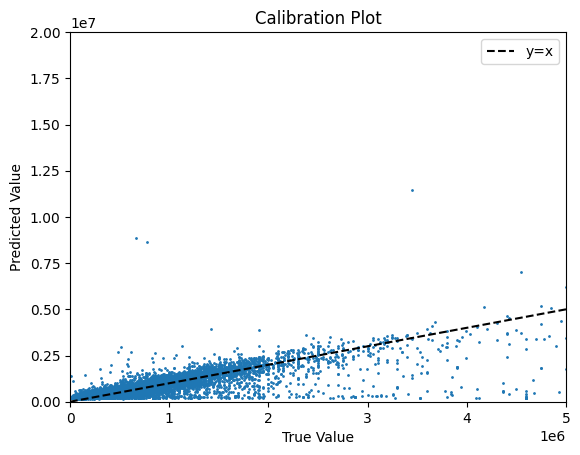

In [66]:
plt.scatter(test['y_true'], test['y_pred'], s=1)
plt.xlim(0, 0.5e7)
plt.ylim(0, 0.2e8)
plt.plot([0, 0.5e7], [0, 0.5e7], 'k--', label='y=x')

# 

plt.xlabel('True Value')
plt.ylabel('Predicted Value')
plt.title('Calibration Plot')
plt.legend()
plt.show()


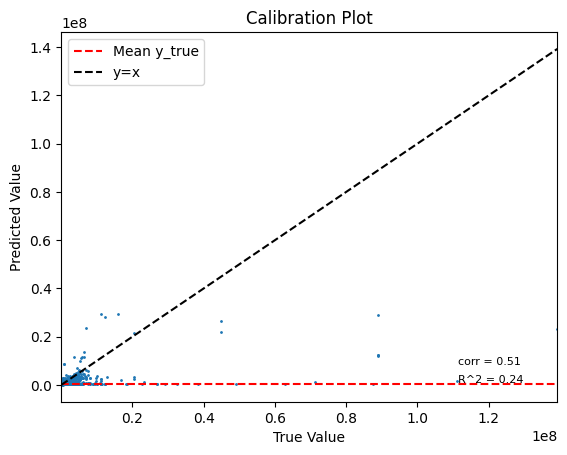

In [67]:
make_calibration_plot(test)

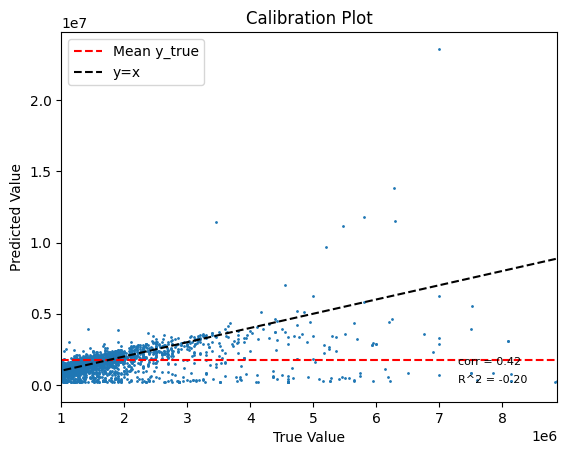

In [68]:
low = 1000000
high = 9000000
make_calibration_plot(test[(test['y_true'] >= low) & (test['y_true'] <= high)])

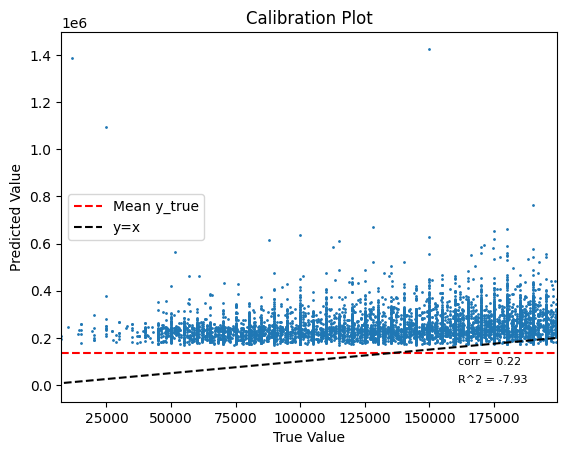

In [69]:
make_calibration_plot(test[test['y_true'] < 200000])

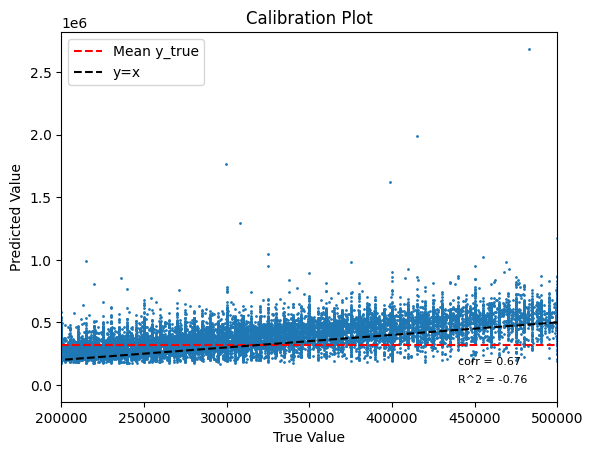

In [70]:
make_calibration_plot(test[(test['y_true'] >= 200000) & (test['y_true'] <= 500000)])

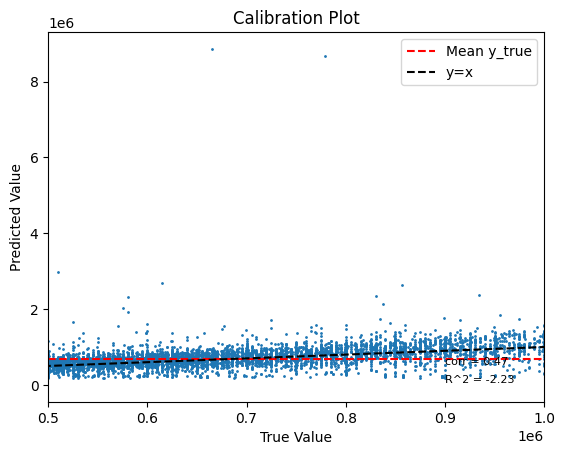

In [71]:
make_calibration_plot(test[(test['y_true'] >= 500000) & (test['y_true'] <= 1000000)])


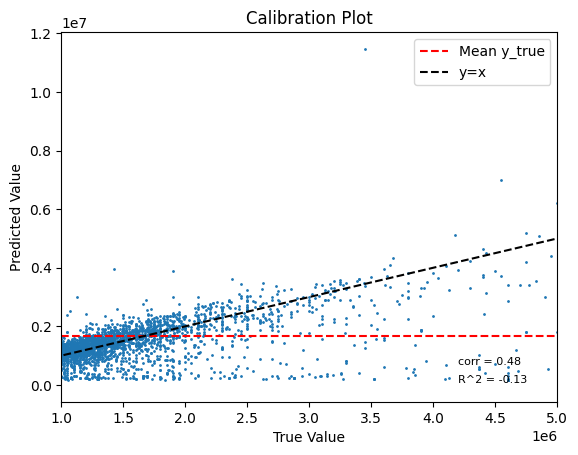

In [72]:
make_calibration_plot(test[(test['y_true'] >= 1000000) & (test['y_true'] <= 5000000)])

In [59]:
temp = test[(test['y_true'] >= 1000000) & (test['y_true'] <= 5000000)]

mse_temp = ((temp['y_true'] - temp['y_pred']) ** 2).mean()

mse_mean = ((temp['y_true'] - temp['y_true'].mean()) ** 2).mean()

print(f'mse_temp: {mse_temp:,.2f}, mse_mean: {mse_mean:,.2f}')


mse_temp: 599,645,477,276.78, mse_mean: 531,572,245,060.14


In [73]:
mae_temp = (np.abs(temp['y_true'] - temp['y_pred'])).mean()
mae_mean = (np.abs(temp['y_true'] - temp['y_true'].mean())).mean()

print(f'mae_temp: {mae_temp:,.2f}, mae_mean: {mae_mean:,.2f}')


mae_temp: 448,119.75, mae_mean: 520,598.32


In [75]:
from sklearn.metrics import mean_absolute_percentage_error

mape_temp = mean_absolute_percentage_error(temp['y_true'], temp['y_pred'])
mape_mean = mean_absolute_percentage_error(temp['y_true'], np.repeat(temp['y_true'].mean(), len(temp)))

print(f'mape_temp: {mape_temp:.2f}, mape_mean: {mape_mean:.2f}')

mape_temp: 0.25, mape_mean: 0.31


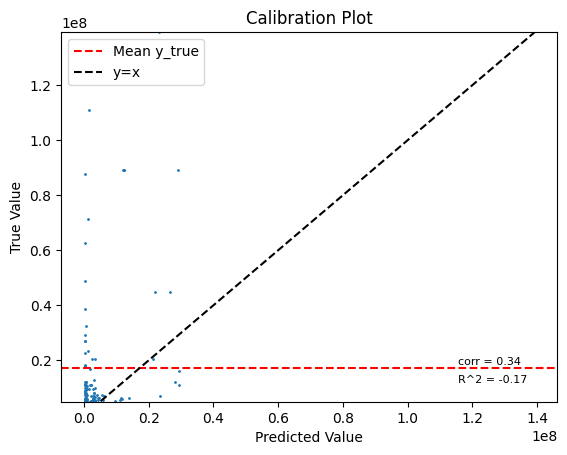

In [47]:
make_calibration_plot(test[(test['y_true'] > 5000000)])

# Seeds 1-40, train sizes 25,50,75,100,200,...,1k, spurious columns dropped from data

In [4]:
df1 = pd.read_csv('../results/dropped-columns-40-seeds/tabpfn.csv')
df2 = pd.read_csv('../results/optuna-dropped-columns-40-seeds/xgboost.csv')

In [5]:
comparison, cols_to_show = get_tabpfn_xgboost_comparison(df1, df2)

In [8]:
df1.head()

,seed,train_size,test_type,n_train,n_test,n_train_cbgs,n_test_cbgs,mae,mse,r2,mean_ratio,median_ratio,std_ratio,train_time,pred_time,status
0,0,25,full,25,39383,24,3537,174605.050366,2.561571e+12,0.040353,0.990182,0.916624,0.583771,33.960076,45.625732,success
1,0,50,full,50,39383,49,3537,154872.150394,2.474911e+12,0.072819,1.086645,0.990331,0.662334,0.778967,27.535998,success
2,0,75,full,75,39383,73,3537,155484.614831,2.497824e+12,0.064234,1.074014,0.982344,0.679087,0.830840,30.768341,success
3,0,100,full,100,39383,97,3537,142123.471611,2.438377e+12,0.086505,1.054562,0.970187,0.698245,0.851100,31.170122,success
4,0,200,full,200,39383,190,3537,138033.230282,2.194922e+12,0.177712,1.082328,0.997877,0.723623,0.836713,88.568861,success


In [49]:
def q25(x):
    return x.quantile(0.25)
def q75(x):
    return x.quantile(0.75)

temp1 = df1.groupby('train_size').agg({'mae': ['median', q25, q75]})
temp2 = df2.groupby('train_size').agg({'mae': ['median', q25, q75]})

# combine temp1 and temp2
temp = pd.concat([temp1, temp2], axis=1)
# temp.columns = ['tabpfn', 'xgboost']
temp.columns = [
    'tabpfn_median', 'tabpfn_q25', 'tabpfn_q75',
    'xgboost_median', 'xgboost_q25', 'xgboost_q75'
]
temp

,tabpfn_median,tabpfn_q25,tabpfn_q75,xgboost_median,xgboost_q25,xgboost_q75
train_size,,,,,,
25,171327.242903,161561.333395,192172.390262,213476.813772,201089.694789,235235.095795
50,161577.226478,150409.282278,174819.505939,198867.852183,190193.583738,212487.747648
75,157919.808588,149106.416152,166482.664788,189476.454136,178634.394687,205472.929959
100,160118.899442,149316.323670,179581.905580,181647.821315,171039.202692,190683.954083
200,154934.474582,147846.424376,164647.869492,169954.725246,162243.461858,185871.855802
300,158232.714245,146511.872828,166117.122113,166321.765445,159326.027951,172094.377206
400,155753.691436,151255.021285,166395.295832,165269.705687,159268.410857,172536.964032
500,155109.072943,148889.648159,164590.915408,164328.226769,156224.395966,174885.747675
600,148597.503995,144766.069656,162279.394289,161549.607520,155870.674597,181780.329127


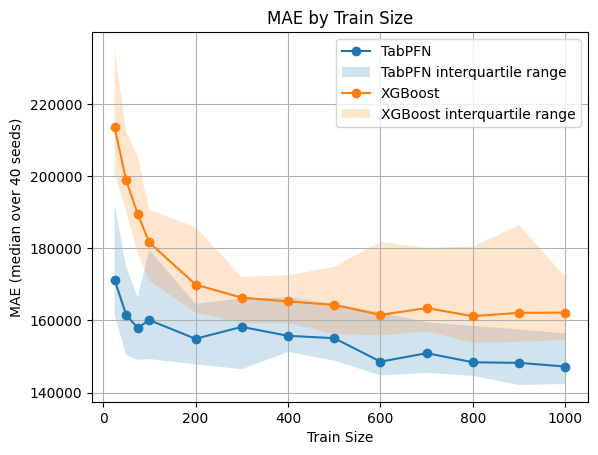

In [52]:
plt.plot(temp.index, temp['tabpfn_median'], label='TabPFN', marker='o')
plt.fill_between(temp.index, temp['tabpfn_q25'], temp['tabpfn_q75'], alpha=0.2, label='TabPFN interquartile range')
plt.plot(temp.index, temp['xgboost_median'], label='XGBoost', marker='o')
plt.fill_between(temp.index, temp['xgboost_q25'], temp['xgboost_q75'], alpha=0.2, label='XGBoost interquartile range')
plt.legend()
plt.xlabel('Train Size')
plt.ylabel('MAE (median over 40 seeds)')
plt.title('MAE by Train Size')
plt.grid()
plt.show()

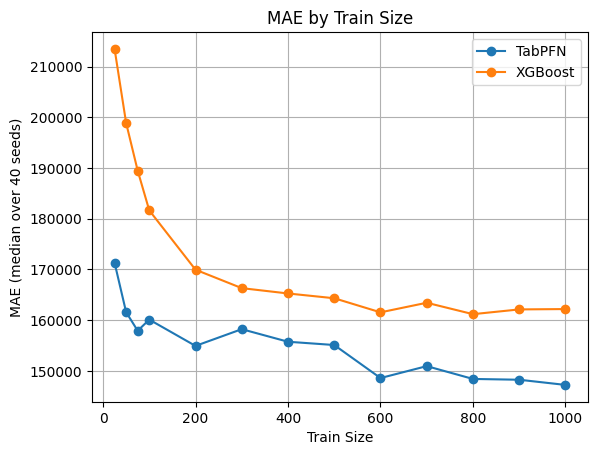

In [24]:
plt.plot(temp.index, temp['tabpfn'], label='TabPFN', marker='o')
plt.plot(temp.index, temp['xgboost'], label='XGBoost', marker='o')
plt.legend()
plt.xlabel('Train Size')
plt.ylabel('MAE (median over 40 seeds)')
plt.title('MAE by Train Size')
plt.grid()
plt.show()


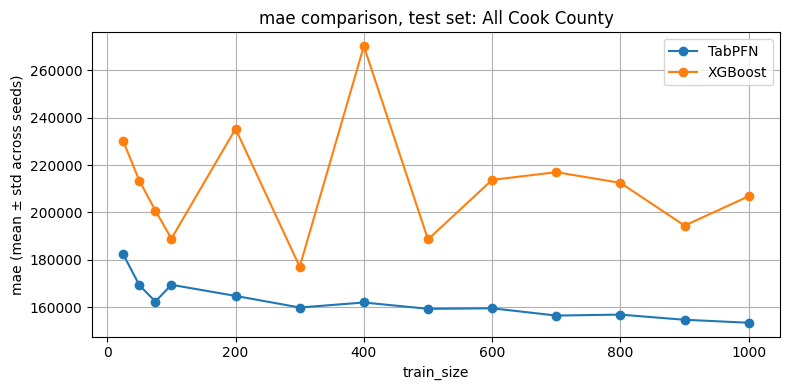

In [26]:
make_comparison_plot(comparison, 'mae', show_std=False)

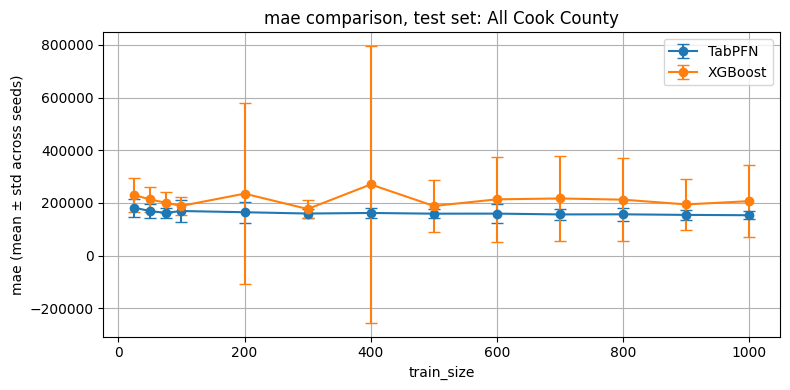

In [27]:
make_comparison_plot(comparison, 'mae')

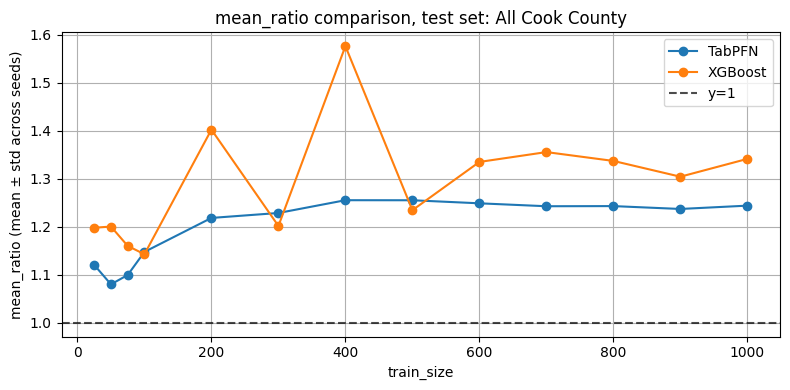

In [28]:
make_comparison_plot(comparison, 'mean_ratio', yline=1, show_std=False)

### Investigate why the ratio of the models is so low for low training sizes

In [11]:
def make_calibration_plot(test):
    plt.scatter(test['y_true'], test['y_pred'], s=1)
    plt.xlabel('True Value')
    plt.ylabel('Predicted Value')
    plt.axhline(test['y_true'].mean(), color='r', linestyle='--', label='Mean y_true')

    #y=x line
    max_true_val = test['y_true'].max()
    plt.plot([0, max_true_val], [0, max_true_val], 'k--', label='y=x')

    # add annotation with r2 score on plot
    # r2 = r2_score(test['y_true'], test['y_pred'])
    # plt.annotate(f'R^2 = {r2:.2f}', xy=(0.8, 0.05), xycoords='axes fraction', fontsize=8)
    # plt.annotate(f'corr = {test["y_true"].corr(test["y_pred"]):.2f}', xy=(0.8, 0.1), xycoords='axes fraction', fontsize=8)

    # limit to 99th percentile  
    plt.xlim(test['y_true'].quantile(0.01), test['y_true'].quantile(0.99))
    plt.ylim(test['y_pred'].quantile(0.01), test['y_pred'].quantile(0.99))

    plt.title('Calibration Plot')
    plt.legend()
    plt.show()
    

In [5]:
indiv2 = pd.read_parquet('/nlp/scr/salilg/cook_county_predictions/dropped-columns-40-seeds/tabpfn/seed5_size50.parquet')

In [13]:
indiv2['ratio'] = indiv2['y_pred'] / indiv2['y_true']
indiv2['ratio'].mean()

np.float64(1.1232534590227652)

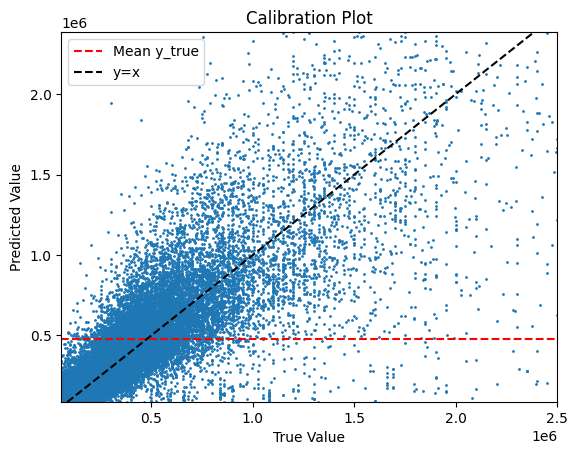

In [12]:
make_calibration_plot(indiv2)

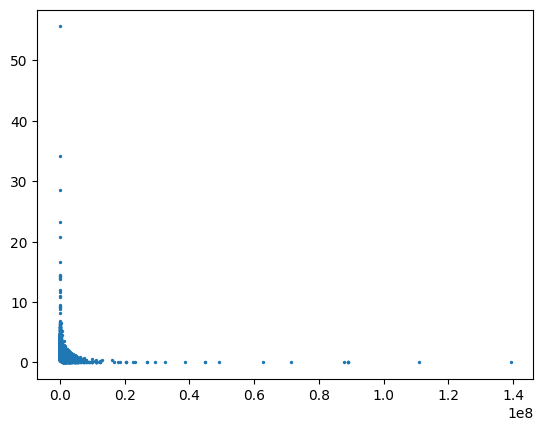

In [15]:
plt.scatter(indiv2['y_true'], indiv2['ratio'], s=2)
# plt.ylim(0, 2)

In [16]:
indiv2['ratio'].describe()

count    39383.000000
mean         1.123253
std          0.672892
min          0.003528
25%          0.817471
50%          1.014497
75%          1.284208
max         55.626647
Name: ratio, dtype: float64

In [17]:
indiv2 = pd.read_parquet('/nlp/scr/salilg/cook_county_predictions/dropped-columns-40-seeds/tabpfn/seed5_size500.parquet')
indiv2['ratio'] = indiv2['y_pred'] / indiv2['y_true']
indiv2['ratio'].mean()

np.float64(1.3216893487501307)

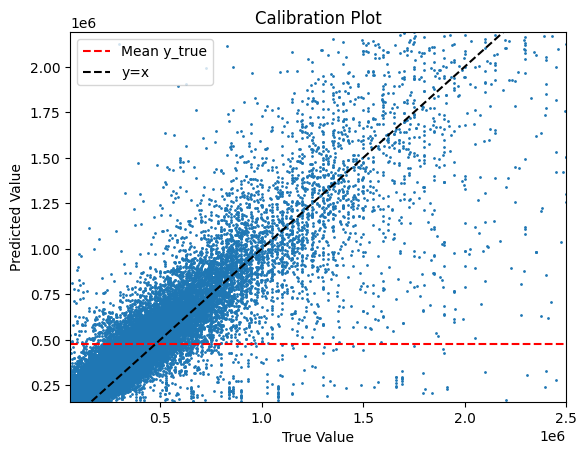

In [18]:
make_calibration_plot(indiv2)

(0.0, 2.0)

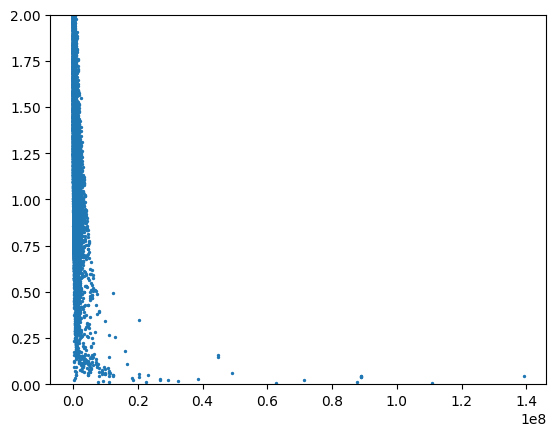

In [20]:
plt.scatter(indiv2['y_true'], indiv2['ratio'], s=2)
plt.ylim(0, 2)

# Calibration plots

## helper functions

### plot

In [85]:
def plot_calibration_by_bin(df, bins=None, figsize=None, alpha=0.1, sample_size=None):
    """
    Create calibration plots (true vs predicted) with one plot per bin.
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame with columns: y_true, y_pred, model, bin
        Optionally can have train_size, seed, test_type for filtering
    bins : list, str, or None
        Which bins to show. If None, show all bins. If list, show only those bins.
        If string, show only that bin.
    figsize : tuple or None
        Figure size (width, height). If None, auto-calculate based on number of bins.
    alpha : float
        Transparency of scatter points (default 0.3)
    sample_size : int or None
        If specified, randomly sample this many points per bin per model for faster plotting
        
    Returns:
    --------
    fig : matplotlib Figure
    axes : array of matplotlib Axes
    """
    # Validate required columns
    required_cols = ['y_true', 'y_pred', 'model', 'bin']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # Get unique bins
    all_bins = sorted(df['bin'].dropna().unique())
    
    # Filter bins if specified
    if bins is None:
        bins = all_bins
    elif isinstance(bins, str):
        bins = [bins]
    else:
        bins = list(bins)
    
    # Validate that requested bins exist
    available_bins = [b for b in bins if b in all_bins]
    missing_bins = [b for b in bins if b not in all_bins]
    
    if missing_bins:
        print(f"Warning: The following bins were not found in the data: {missing_bins}")
        print(f"Available bins: {all_bins}")
    
    if not available_bins:
        print("Error: No valid bins to plot. Please check your bin selection.")
        return None, None
    
    bins = sorted(available_bins)
    n_bins = len(bins)
    
    # Get models
    models = sorted(df['model'].unique())
    model_colors = {'tabpfn': '#1f77b4', 'xgboost': '#ff7f0e'}  # Blue for TabPFN, Orange for XGBoost
    
    # Calculate figure size if not provided
    cols = min(3, n_bins)
    rows = (n_bins + cols - 1) // cols
    if figsize is None:
        figsize = (5 * cols, 4 * rows)
    
    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    
    # Plot each bin
    for idx, bin_val in enumerate(bins):
        ax = axes[idx]
        
        # Filter data for this bin
        bin_data = df[df['bin'] == bin_val].copy()
        
        if len(bin_data) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{bin_val}', fontsize=12)
            continue
        
        # Plot each model
        for model in models:
            model_data = bin_data[bin_data['model'] == model].copy()
            
            if len(model_data) == 0:
                continue
            
            # Sample if requested
            if sample_size is not None and len(model_data) > sample_size:
                model_data = model_data.sample(n=sample_size, random_state=42)
            
            y_true = model_data['y_true'].values
            y_pred = model_data['y_pred'].values
            
            # Get color for this model
            color = model_colors.get(model, None)
            if color is None:
                # Use default color cycle if model not in dict
                color = plt.cm.tab10(list(models).index(model))
            
            # Scatter plot
            ax.scatter(y_true, y_pred, alpha=alpha, s=10, label=model, color=color)
        
        # Add perfect calibration line (y=x)
        # Get data range for reference line
        all_y_true = bin_data['y_true'].values
        all_y_pred = bin_data['y_pred'].values
        min_val = min(all_y_true.min(), all_y_pred.min())
        max_val = max(all_y_true.max(), all_y_pred.max())
        
        ax.plot([min_val, max_val], [min_val, max_val], 
                'k--', alpha=0.5, linewidth=1.5, label='Perfect calibration')
        
        # Labels and title
        ax.set_xlabel('True Value', fontsize=10)
        if idx % cols == 0:  # Only label y-axis on leftmost plots
            ax.set_ylabel('Predicted Value', fontsize=10)
        ax.set_title(f'{bin_val}', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        
        # Make axes equal aspect ratio for better calibration visualization
        # ax.set_aspect('equal', adjustable='box')
    
    # Hide unused subplots
    for idx in range(n_bins, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes


### read data

In [77]:
# Sample code to load prediction data from parquet files for calibration plots

from pathlib import Path

def load_predictions_for_calibration(
    tabpfn_dir='/nlp/scr/salilg/cook_county_predictions/tabpfn/',
    xgboost_dir='/nlp/scr/salilg/cook_county_predictions/xgboost/',
    train_sizes=None,
    seeds=None,
    test_type='full',
    bin_edges=None,
    bin_labels=None
):
    """
    Load predictions from parquet files and prepare for calibration plots.
    
    Parameters:
    -----------
    tabpfn_dir : str
        Directory containing TabPFN prediction parquet files
    xgboost_dir : str
        Directory containing XGBoost prediction parquet files
    train_sizes : list or None
        Filter to specific train sizes (None = use all)
    seeds : list or None
        Filter to specific seeds (None = use all)
    test_type : str
        Filter to specific test type ('full' or 'cbg_matched')
    bin_edges : list or None
        Bin edges for creating bins (None = use default)
    bin_labels : list or None
        Bin labels (None = use default)
        
    Returns:
    --------
    df : DataFrame
        DataFrame with columns: y_true, y_pred, model, bin
    """
    # Default bin edges and labels (same as in analyze_predictions_by_bins.py)
    if bin_edges is None:
        bin_edges = [
            0,           # < 200k
            200_000,     # 200k - 500k
            500_000,     # 500k - 1M
            1_000_000,   # 1M - 2M
            2_000_000,   # 2M - 10M
            10_000_000,  # 10M+
            np.inf
        ]
    
    if bin_labels is None:
        bin_labels = [
            '<200k',
            '200k-500k',
            '500k-1M',
            '1M-2M',
            '2M-10M',
            '10M+'
        ]
    
    def load_model_predictions(pred_dir, model_name):
        """Load all parquet files for a model."""
        pred_path = Path(pred_dir)
        
        if not pred_path.exists():
            print(f"Warning: Directory not found: {pred_dir}")
            return pd.DataFrame()
        
        parquet_files = list(pred_path.glob('*.parquet'))
        
        if not parquet_files:
            print(f"Warning: No parquet files found in {pred_dir}")
            return pd.DataFrame()
        
        print(f"Loading {len(parquet_files)} files for {model_name}...")
        
        dfs = []
        for file in parquet_files:
            try:
                df = pd.read_parquet(file)
                
                # Apply filters
                if train_sizes is not None and 'train_size' in df.columns:
                    df = df[df['train_size'].isin(train_sizes)]
                
                if seeds is not None and 'seed' in df.columns:
                    df = df[df['seed'].isin(seeds)]
                
                if test_type is not None and 'test_type' in df.columns:
                    df = df[df['test_type'] == test_type]
                
                if len(df) > 0:
                    df['model'] = model_name
                    dfs.append(df)
                    
            except Exception as e:
                print(f"Warning: Failed to load {file}: {e}")
        
        if not dfs:
            return pd.DataFrame()
        
        combined = pd.concat(dfs, ignore_index=True)
        print(f"Loaded {len(combined)} predictions for {model_name}")
        return combined
    
    # Load predictions for both models
    tabpfn_df = load_model_predictions(tabpfn_dir, 'tabpfn')
    xgboost_df = load_model_predictions(xgboost_dir, 'xgboost')
    
    # Combine both models
    if tabpfn_df.empty and xgboost_df.empty:
        print("Error: No predictions loaded!")
        return pd.DataFrame()
    
    if tabpfn_df.empty:
        combined_df = xgboost_df
    elif xgboost_df.empty:
        combined_df = tabpfn_df
    else:
        combined_df = pd.concat([tabpfn_df, xgboost_df], ignore_index=True)
    
    # Create bins based on y_true
    combined_df['bin'] = pd.cut(
        combined_df['y_true'], 
        bins=bin_edges, 
        labels=bin_labels, 
        include_lowest=True
    )
    
    # Select only columns needed for calibration plot
    result_df = combined_df[['y_true', 'y_pred', 'model', 'bin']].copy()
    
    # Remove rows with NaN bins (outside bin edges)
    result_df = result_df.dropna(subset=['bin'])
    
    print(f"\nTotal predictions loaded: {len(result_df)}")
    print(f"Bins: {result_df['bin'].value_counts().sort_index()}")
    print(f"Models: {result_df['model'].value_counts()}")
    
    return result_df


# Example usage:
# Load all predictions
# df_calibration = load_predictions_for_calibration()

# Load specific train sizes and seeds
# df_calibration = load_predictions_for_calibration(
#     train_sizes=[100, 200, 300],
#     seeds=[0, 1, 2, 3]
# )

# Then use with the calibration plot function:
# plot_calibration_by_bin(df_calibration)


## actual plotting

In [78]:
df_calibration = load_predictions_for_calibration(
    train_sizes=[100],
    seeds=range(20)
)

Loading 200 files for tabpfn...
Loaded 200000 predictions for tabpfn
Loading 215 files for xgboost...
Loaded 200000 predictions for xgboost

Total predictions loaded: 400000
Bins: bin
<200k         81428
200k-500k    228788
500k-1M       64028
1M-2M         19876
2M-10M         5466
10M+            414
Name: count, dtype: int64
Models: model
tabpfn     200000
xgboost    200000
Name: count, dtype: int64


In [81]:
df_calibration.head()

,y_true,y_pred,model,bin
0,165000.0,259153.59375,tabpfn,<200k
1,775000.0,818385.62500,tabpfn,500k-1M
2,240000.0,359103.75000,tabpfn,200k-500k
3,390000.0,425425.37500,tabpfn,200k-500k
4,275000.0,209532.56250,tabpfn,200k-500k


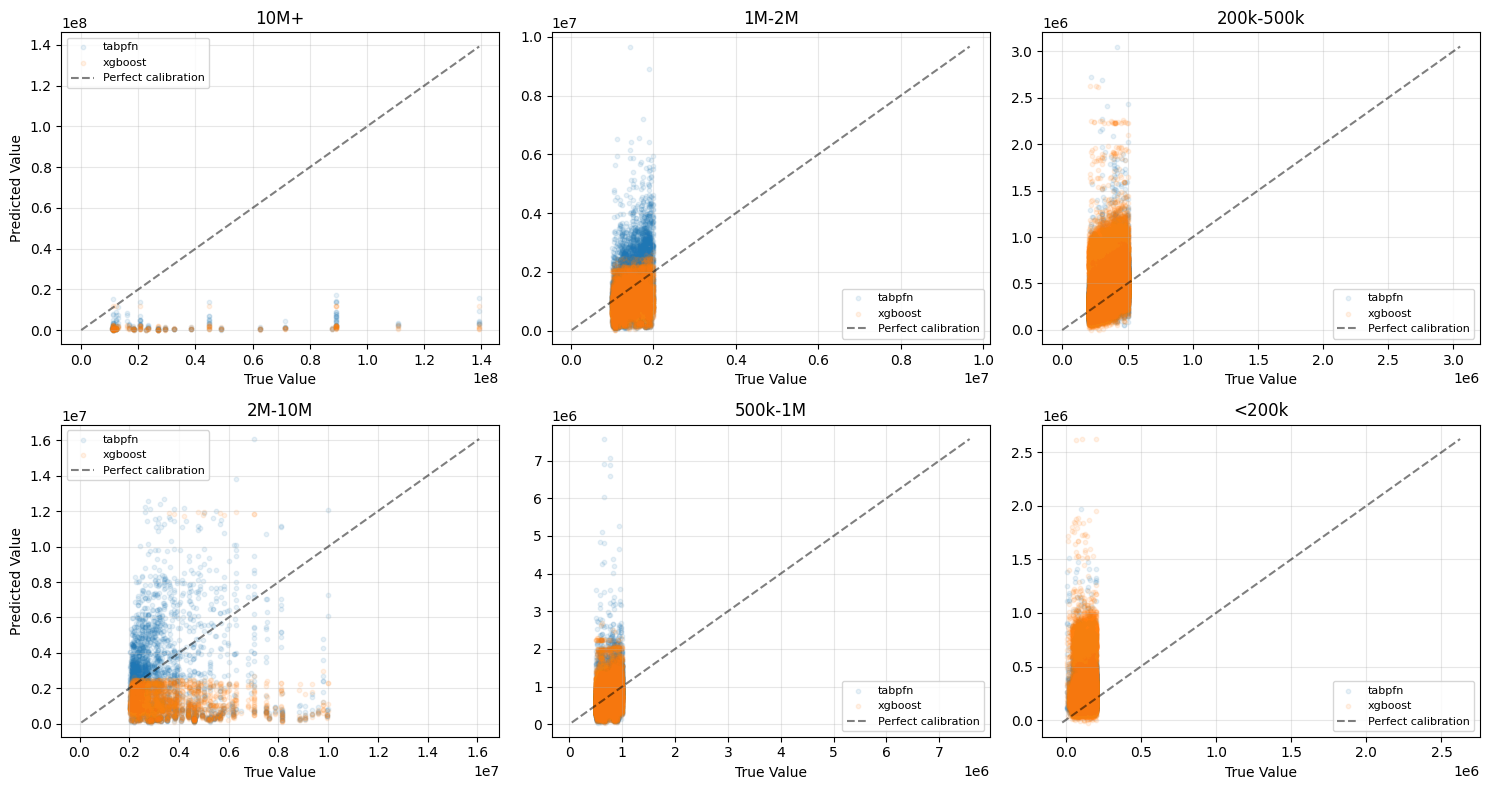

(<Figure size 1500x800 with 6 Axes>,
 array([<Axes: title={'center': '10M+'}, xlabel='True Value', ylabel='Predicted Value'>,
        <Axes: title={'center': '1M-2M'}, xlabel='True Value'>,
        <Axes: title={'center': '200k-500k'}, xlabel='True Value'>,
        <Axes: title={'center': '2M-10M'}, xlabel='True Value', ylabel='Predicted Value'>,
        <Axes: title={'center': '500k-1M'}, xlabel='True Value'>,
        <Axes: title={'center': '<200k'}, xlabel='True Value'>],
       dtype=object))

In [86]:
plot_calibration_by_bin(df_calibration)

# Inspect within CBG predictions

In [29]:
df1 = pd.read_csv('../results/by_cbg/tabpfn_within_cbg_results.csv')
df2 = pd.read_csv('../results/by_cbg/xgboost_within_cbg_results.csv')

In [30]:
# take mean over cbg_id but keep rows in terms of seed and train_size
df1_test = df1.drop(columns=['status', 'model']).groupby(['seed', 'train_size']).mean().drop(columns=['cbg_id']).reset_index()
df2_test = df2.drop(columns=['status', 'model']).groupby(['seed', 'train_size']).mean().drop(columns=['cbg_id']).reset_index()

In [31]:
comparison, cols_to_show = get_tabpfn_xgboost_comparison(df1_test, df2_test)

In [32]:
comparison

,tabpfn__mae_mean,tabpfn__mae_std,tabpfn__mse_mean,tabpfn__mse_std,tabpfn__r2_mean,tabpfn__r2_std,tabpfn__mean_ratio_mean,tabpfn__mean_ratio_std,tabpfn__median_ratio_mean,tabpfn__median_ratio_std,...,xgboost__median_ratio_std,xgboost__std_ratio_mean,xgboost__std_ratio_std,xgboost__seed_count,delta__mae_mean,delta__mse_mean,delta__r2_mean,delta__mean_ratio_mean,delta__median_ratio_mean,delta__std_ratio_mean
train_size,,,,,,,,,,,,,,,,,,,,,
25,125752.580397,4632.081452,1.041244e+12,6.608541e+09,0.143411,0.129596,1.115203,0.020801,1.028948,0.012891,...,0.017178,0.492661,0.028431,10,-9038.650464,-6.643033e+09,0.043756,0.017698,0.015618,-0.019176
50,117764.568321,3106.728327,1.034982e+12,7.758590e+09,0.230164,0.063534,1.110877,0.011377,1.025168,0.008683,...,0.011067,0.463667,0.020066,10,-8224.797938,-2.379406e+09,0.081504,0.006142,0.004665,-0.001490
75,113821.420958,2418.872710,1.030863e+12,3.192870e+09,0.284918,0.087346,1.104528,0.007156,1.021769,0.004445,...,0.003605,0.450163,0.021022,10,-7415.263844,-4.047376e+09,0.071452,0.001857,0.000832,-0.002682
100,111524.279478,2123.799525,1.028387e+12,2.824528e+09,0.327973,0.065674,1.101201,0.007550,1.019432,0.002881,...,0.003728,0.461955,0.024276,10,-7434.337573,-1.112999e+10,0.187470,-0.001545,0.002788,-0.024502


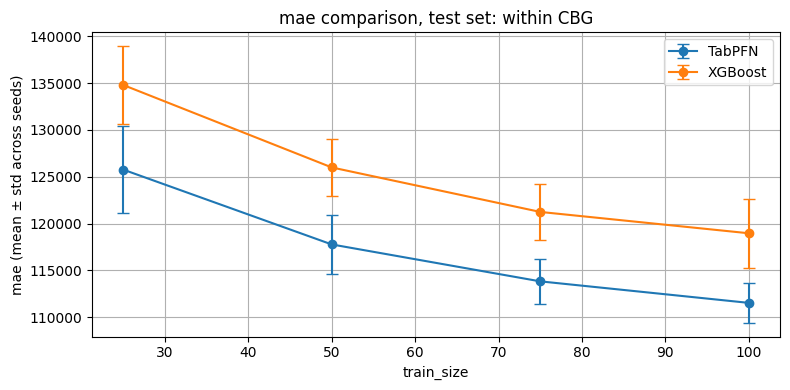

In [37]:
make_comparison_plot(comparison, 'mae', test_set='within CBG')

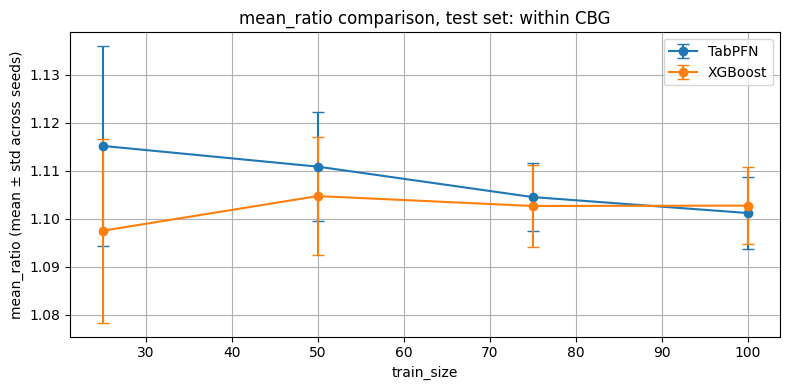

In [36]:
make_comparison_plot(comparison, 'mean_ratio', test_set='within CBG')

# train sizes 25, 50, 75, 100, ..., 1k, 2k, ..., 10k; 40 seeds, dropped columns

In [53]:
df = pd.read_csv('../results/upto10ktrain-dropped-columns-40-seeds/xgboost.csv')

In [62]:
temp = df.groupby('train_size').agg({'mae': ['mean', 'median', q25, q75]})
temp.columns = ['xgboost_mae_mean', 'xgboost_mae_median', 'xgboost_mae_q25', 'xgboost_mae_q75']

In [65]:
temp['xgboost_mae_median']

train_size
100      180134.265290
300      165781.375850
500      163378.137071
700      165825.523783
900      163760.117992
1000     163483.711011
2000     169321.476960
3000     177091.802195
4000     176773.101817
5000     200016.889616
6000     200107.197016
7000     186553.469640
8000     201592.532497
9000     202215.348382
10000    206854.128377
Name: xgboost_mae_median, dtype: float64

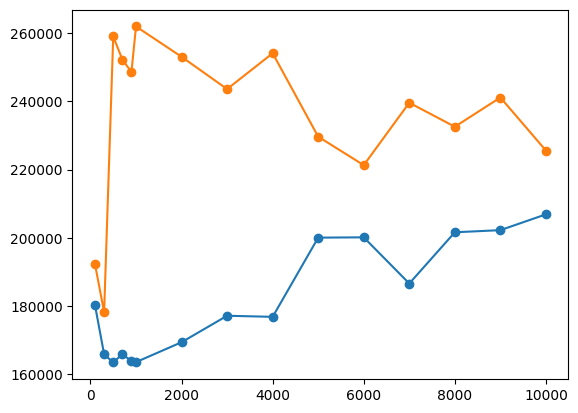

In [63]:
plt.plot(temp.index, temp['xgboost_mae_median'], label='XGBoost', marker='o')
plt.plot(temp.index, temp['xgboost_mae_mean'], label='XGBoost (mean)', marker='o')

In [66]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('../results/upto10ktrain-dropped-columns-40-seeds/xgboost.csv')

# Check if all experiments succeeded
print("Status counts:")
print(df['status'].value_counts())
print()

# Look at a few specific seeds to see if pattern is consistent
print("MAE by train_size for seed=0:")
seed0 = df[df['seed'] == 0].sort_values('train_size')[['train_size', 'mae', 'r2']]
print(seed0)
print()

print("MAE by train_size for seed=1:")
seed1 = df[df['seed'] == 1].sort_values('train_size')[['train_size', 'mae', 'r2']]
print(seed1)

Status counts:
status
success    600
Name: count, dtype: int64

MAE by train_size for seed=0:
    train_size            mae        r2
0          100  167767.210793  0.041744
1          300  168161.035409  0.072181
2          500  167202.937791  0.063081
3          700  164855.589260  0.058995
4          900  158806.021435  0.053278
5         1000  151978.734642  0.077111
6         2000  172380.959377  0.088436
7         3000  165869.218429  0.093199
8         4000  162203.355217  0.098470
9         5000  199458.998064  0.103753
10        6000  203373.832071  0.101368
11        7000  152120.528011  0.116229
12        8000  170294.043061  0.119479
13        9000  202458.926207  0.185495
14       10000  206698.707534  0.184669

MAE by train_size for seed=1:
    train_size            mae        r2
15         100  184907.773592  0.041679
16         300  158219.115574  0.072850
17         500  158338.461641  0.082441
18         700  152228.562587  0.093376
19         900  147480.238636  0.08

In [67]:
# Let's look at the variance across seeds for each train_size
print("MAE statistics by train_size:")
mae_stats = df.groupby('train_size')['mae'].agg(['mean', 'median', 'std', 'min', 'max'])
print(mae_stats)
print()

# Look at R2 to understand what's happening
print("R2 statistics by train_size:")
r2_stats = df.groupby('train_size')['r2'].agg(['mean', 'median', 'std', 'min', 'max'])
print(r2_stats)
print()

# Check how many outliers we have (very bad MAE)
print("Count of MAE > 250k by train_size:")
print(df[df['mae'] > 250000].groupby('train_size').size())

MAE statistics by train_size:
                     mean         median            std            min  \
train_size                                                               
100         192202.569368  180134.265290   44738.281692  159413.551082   
300         178129.203296  165781.375850   38586.223798  151846.492829   
500         259080.929221  163378.137071  285246.342339  150253.167666   
700         252285.037521  165825.523783  234987.006868  150634.758006   
900         248618.223302  163760.117992  217528.105694  147480.238636   
1000        261992.551489  163483.711011  291353.778582  146153.700983   
2000        253097.313271  169321.476960  226965.956059  144004.357300   
3000        243617.283882  177091.802195  246461.266590  145081.792248   
4000        254134.122617  176773.101817  224250.817309  143172.538775   
5000        229648.786898  200016.889616  143180.938612  142743.076809   
6000        221290.129442  200107.197016   88004.649382  145637.923818   
7000    

In [68]:
# Find the worst performing runs
print("Worst performing runs (MAE > 500k):")
worst_runs = df[df['mae'] > 500000].sort_values('mae', ascending=False)
print(worst_runs[['seed', 'train_size', 'mae', 'r2', 'n_train', 'n_train_cbgs']].head(20))
print()

# Check if certain seeds are consistently problematic
print("Number of 'catastrophic' runs (MAE > 500k) by seed:")
catastrophic = df[df['mae'] > 500000].groupby('seed').size().sort_values(ascending=False)
print(catastrophic.head(15))
print()

# Look at the tune_time for failed vs successful runs
print("Tune time comparison:")
print(f"Normal runs (MAE < 250k): mean={df[df['mae'] < 250000]['tune_time'].mean():.2f}s")
print(f"Bad runs (MAE > 500k): mean={df[df['mae'] > 500000]['tune_time'].mean():.2f}s")

Worst performing runs (MAE > 500k):
     seed  train_size           mae        r2  n_train  n_train_cbgs
287    19         500  1.623240e+06 -3.579063      500           448
65      4        1000  1.541390e+06 -1.047879     1000           830
562    37        3000  1.453487e+06 -0.817564     3000          1764
411    27        2000  1.355517e+06 -0.829511     2000          1359
413    27        4000  1.265608e+06 -4.028698     4000          2059
485    32        1000  1.225017e+06 -0.441951     1000           825
123     8         700  1.194688e+06 -0.397133      700           597
288    19         700  1.113287e+06 -0.337513      700           597
484    32         900  1.087564e+06 -0.317109      900           755
412    27        3000  1.078752e+06 -2.886812     3000          1751
414    27        5000  1.030357e+06 -2.997560     5000          2258
122     8         500  9.835169e+05 -0.234401      500           435
563    37        4000  9.713516e+05 -0.351938     4000          203

In [69]:
# Let's look at the actual best parameters found for good vs bad runs
print("Sample of hyperparameters for GOOD runs (MAE < 170k):")
good_seeds = df[(df['mae'] < 170000) & (df['train_size'] >= 5000)].head(5)
print(good_seeds[['seed', 'train_size', 'mae', 'r2']])
print()

print("Sample of hyperparameters for BAD runs (MAE > 500k):")
bad_seeds = df[df['mae'] > 500000].head(5)
print(bad_seeds[['seed', 'train_size', 'mae', 'r2', 'n_train']])
print()

# Check if there's correlation between n_train_cbgs and performance
print("For train_size=5000-10000, check if n_train_cbgs differs between good/bad runs:")
large_train = df[df['train_size'] >= 5000]
good_large = large_train[large_train['mae'] < 250000]
bad_large = large_train[large_train['mae'] > 500000]

print(f"Good runs: mean n_train_cbgs = {good_large['n_train_cbgs'].mean():.0f}")
print(f"Bad runs: mean n_train_cbgs = {bad_large['n_train_cbgs'].mean():.0f}")
print()

# Check if bad runs are finding pathological hyperparameters
# by looking at the seed pattern more carefully
print("Looking at seed 27 (7 catastrophic failures):")
seed27 = df[df['seed'] == 27].sort_values('train_size')
print(seed27[['train_size', 'mae', 'r2', 'n_train']])

Sample of hyperparameters for GOOD runs (MAE < 170k):
    seed  train_size            mae        r2
11     0        7000  152120.528011  0.116229
24     1        5000  145943.432291  0.131782
25     1        6000  146427.799632  0.141740
28     1        9000  166075.719832  0.118935
39     2        5000  156721.211976  0.169704

Sample of hyperparameters for BAD runs (MAE > 500k):
    seed  train_size           mae        r2  n_train
62     4         500  7.931252e+05 -0.271989      500
63     4         700  6.494920e+05 -0.300693      700
64     4         900  5.397819e+05  0.045709      900
65     4        1000  1.541390e+06 -1.047879     1000
77     5         500  7.102823e+05 -0.040427      500

For train_size=5000-10000, check if n_train_cbgs differs between good/bad runs:
Good runs: mean n_train_cbgs = 2591
Bad runs: mean n_train_cbgs = 2543

Looking at seed 27 (7 catastrophic failures):
     train_size           mae        r2  n_train
405         100  1.842219e+05  0.029644     

In [70]:
# My hypothesis: certain seeds are sampling pathological training sets
# Let's check if there's something unique about the training samples for bad seeds

# Check how the median behaves if we exclude the catastrophic seeds
catastrophic_seeds = [27, 4, 19, 37, 8, 32]

print("Median MAE by train_size (ALL seeds):")
print(df.groupby('train_size')['mae'].median())
print()

print("Median MAE by train_size (EXCLUDING catastrophic seeds):")
df_clean = df[~df['seed'].isin(catastrophic_seeds)]
print(df_clean.groupby('train_size')['mae'].median())
print()

print(f"Total runs: {len(df)}, Excluded: {len(df[df['seed'].isin(catastrophic_seeds)])}, Remaining: {len(df_clean)}")

Median MAE by train_size (ALL seeds):
train_size
100      180134.265290
300      165781.375850
500      163378.137071
700      165825.523783
900      163760.117992
1000     163483.711011
2000     169321.476960
3000     177091.802195
4000     176773.101817
5000     200016.889616
6000     200107.197016
7000     186553.469640
8000     201592.532497
9000     202215.348382
10000    206854.128377
Name: mae, dtype: float64

Median MAE by train_size (EXCLUDING catastrophic seeds):
train_size
100      179551.014366
300      164293.859206
500      162008.547789
700      165197.090700
900      159726.635765
1000     161815.247213
2000     160650.174370
3000     168136.546194
4000     166641.065413
5000     185504.810731
6000     189833.429013
7000     186553.469640
8000     195637.767871
9000     196197.613639
10000    203495.952420
Name: mae, dtype: float64

Total runs: 600, Excluded: 90, Remaining: 510


FileNotFoundError: [Errno 2] No such file or directory: '../figures/catastrophic_seeds_impact.png'

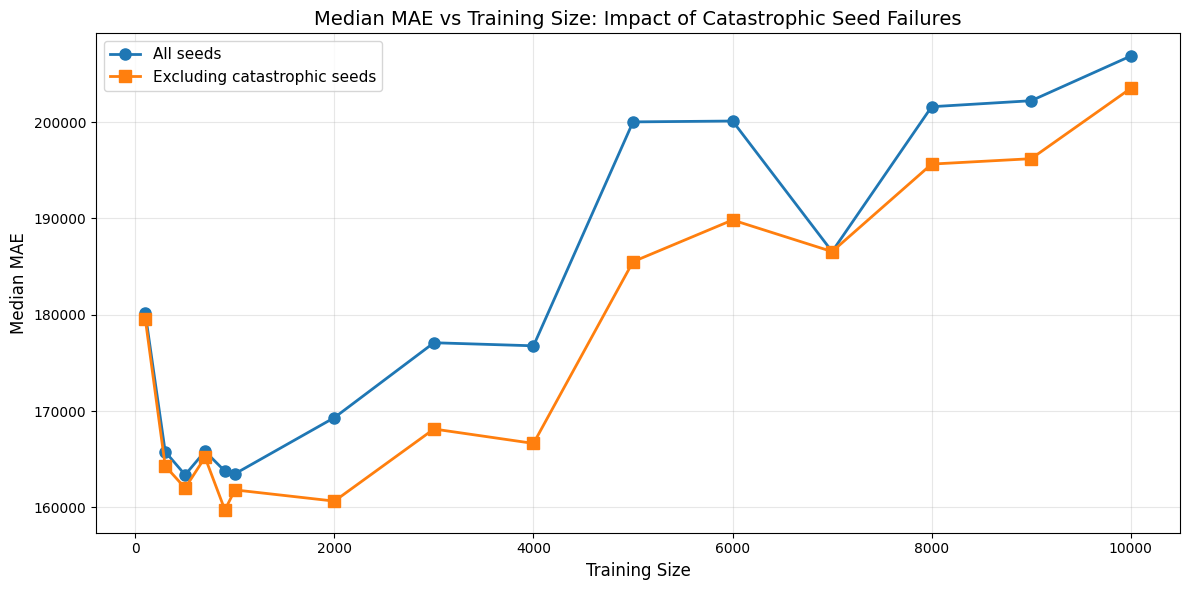

In [71]:
import matplotlib.pyplot as plt

# Create a plot comparing median MAE with and without catastrophic seeds
train_sizes = sorted(df['train_size'].unique())
median_all = df.groupby('train_size')['mae'].median()
median_clean = df_clean.groupby('train_size')['mae'].median()

plt.figure(figsize=(12, 6))
plt.plot(train_sizes, median_all, 'o-', label='All seeds', linewidth=2, markersize=8)
plt.plot(train_sizes, median_clean, 's-', label='Excluding catastrophic seeds', linewidth=2, markersize=8)
plt.xlabel('Training Size', fontsize=12)
plt.ylabel('Median MAE', fontsize=12)
plt.title('Median MAE vs Training Size: Impact of Catastrophic Seed Failures', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/catastrophic_seeds_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to figures/catastrophic_seeds_impact.png")

In [72]:
# Let me look at what's actually happening with the data
# My hypothesis: there's something wrong with the training data sampling or data leakage

# First, let's see if this is specific to XGBoost or a data issue
# Check if there are any patterns in the training data itself

print("Looking at the relationship between train_size and actual training characteristics:")
print("\nMean values by train_size:")
print(df.groupby('train_size')[['n_train', 'n_train_cbgs', 'mae', 'r2']].mean())
print()

# Check if the ratio of samples to CBGs changes
df['samples_per_cbg'] = df['n_train'] / df['n_train_cbgs']
print("Samples per CBG by train_size:")
print(df.groupby('train_size')['samples_per_cbg'].agg(['mean', 'median', 'std']))

Looking at the relationship between train_size and actual training characteristics:

Mean values by train_size:
            n_train  n_train_cbgs            mae        r2
train_size                                                
100           100.0        97.925  192202.569368  0.014875
300           300.0       282.050  178129.203296  0.061717
500           500.0       449.400  259080.929221 -0.160150
700           700.0       603.800  252285.037521 -0.167336
900           900.0       747.100  248618.223302 -0.172127
1000         1000.0       815.450  261992.551489 -0.157118
2000         2000.0      1369.125  253097.313271  0.012210
3000         3000.0      1766.275  243617.283882 -0.014339
4000         4000.0      2054.725  254134.122617 -0.006450
5000         5000.0      2271.675  229648.786898  0.034722
6000         6000.0      2439.775  221290.129442  0.111266
7000         7000.0      2575.575  239608.942738  0.021610
8000         8000.0      2687.525  232569.951855  0.017775
900

In [ ]:
# This is very interesting - the samples per CBG increases linearly
# This means as we sample more data, we're getting more samples from the SAME CBGs
# This could cause overfitting to specific CBGs

# Let me check: what if the test set has different CBG distribution than training?
# Or what if sampling multiple sales from the same CBG causes issues?

# Let's look at the actual data to understand the CBG distribution
import sys
sys.path.insert(0, '/sailhome/salilg/tabpfn_data_scarcity/cook_county_analysis')

from src.data_utils import load_and_prepare_data

# Load the actual data
X_train_pool, y_train_pool, X_test, y_test, cbg_column = load_and_prepare_data(
    '../data/cook_county.csv', 'block_group_id'
)

print(f"Train pool size: {len(X_train_pool)}")
print(f"Test set size: {len(X_test)}")
print(f"Unique CBGs in train pool: {X_train_pool[cbg_column].nunique()}")
print(f"Unique CBGs in test set: {X_test[cbg_column].nunique()}")
print()

# Check the distribution of samples per CBG
train_cbg_counts = X_train_pool[cbg_column].value_counts()
test_cbg_counts = X_test[cbg_column].value_counts()

print(f"Train pool - samples per CBG statistics:")
print(train_cbg_counts.describe())
print()


print(f"Test set - samples per CBG statistics:")
print(test_cbg_counts.describe())

Train pool size: 170539
Test set size: 39383
Unique CBGs in train pool: 3785
Unique CBGs in test set: 3537

Train pool - samples per CBG statistics:
count    3785.000000
mean       45.040159
std        37.247884
min         1.000000
25%        15.000000
50%        38.000000
75%        66.000000
max       374.000000
Name: count, dtype: float64

Test set - samples per CBG statistics:
count    3537.000000
mean       11.099519
std         9.007993
min         1.000000
25%         4.000000
50%         9.000000
75%        16.000000
max        74.000000
Name: count, dtype: float64


In [74]:
# This is revealing! The train pool has ~45 samples per CBG on average
# but the test set only has ~11 samples per CBG on average

# This means when we sample 10,000 training examples, we're getting ~3.5 samples per CBG
# which is CLOSER to the test distribution than when we sample 100 examples (1 sample per CBG)

# Wait, let me think about this differently...
# Maybe the issue is that we're using the FULL test set regardless of which CBGs appear in training

# Let's check: do they use test_type='full' or 'cbg_matched'?
print("Test type used in experiment:")
print(df['test_type'].unique())
print()

# Let's see what fraction of test samples come from CBGs seen in training
print("For different train sizes, what % of test set comes from training CBGs?")
# The n_test should be constant if using full test set
print(df.groupby('train_size')['n_test'].agg(['min', 'max', 'mean']))
print()

# All have n_test = 39383, so they're using the FULL test set
# This means they're evaluating on CBGs that may not be in the training set at all!

# Let's check overlap
print("CBG overlap between train and test:")
train_cbgs = set(X_train_pool[cbg_column].dropna().unique())
test_cbgs = set(X_test[cbg_column].dropna().unique())
overlap = train_cbgs & test_cbgs
print(f"Train CBGs: {len(train_cbgs)}")
print(f"Test CBGs: {len(test_cbgs)}")  
print(f"Overlap: {len(overlap)} ({len(overlap)/len(test_cbgs)*100:.1f}% of test CBGs)")
print(f"Test-only CBGs: {len(test_cbgs - overlap)}")

Test type used in experiment:
['full']

For different train sizes, what % of test set comes from training CBGs?
              min    max     mean
train_size                       
100         39383  39383  39383.0
300         39383  39383  39383.0
500         39383  39383  39383.0
700         39383  39383  39383.0
900         39383  39383  39383.0
1000        39383  39383  39383.0
2000        39383  39383  39383.0
3000        39383  39383  39383.0
4000        39383  39383  39383.0
5000        39383  39383  39383.0
6000        39383  39383  39383.0
7000        39383  39383  39383.0
8000        39383  39383  39383.0
9000        39383  39383  39383.0
10000       39383  39383  39383.0

CBG overlap between train and test:
Train CBGs: 3785
Test CBGs: 3537
Overlap: 3504 (99.1% of test CBGs)
Test-only CBGs: 33


In [75]:
# Good, so 99% of test CBGs are in training pool, so that's not the issue

# Let me think about what happens as we increase training size:
# - At train_size=100: we sample ~100 CBGs, ~1 sample per CBG
# - At train_size=10000: we sample ~2860 CBGs, ~3.5 samples per CBG

# The key insight: as training size increases, we're covering more CBGs BUT ALSO
# getting more repeated samples from the same CBG

# Hypothesis: The model is learning CBG-specific patterns (overfitting to CBG IDs indirectly)
# and this hurts generalization

# But wait - they DROP the CBG column before training! Let me verify
print("Features used for training (from prepare_features_for_model):")
print("CBG column is dropped:", cbg_column not in X_train_pool.columns or "keep_cbg=False")
print()

# So the model doesn't see CBG IDs directly...
# But maybe there are other features that proxy for CBG?

print("Feature columns in training data:")
print(X_train_pool.columns.tolist())
print()
print(f"Number of features: {len(X_train_pool.columns)}")

Features used for training (from prepare_features_for_model):
CBG column is dropped: keep_cbg=False

Feature columns in training data:
['latitude', 'longitude', 'meta_sfh', 'char_yrblt', 'char_yrblt_miss', 'char_air_central', 'char_air_miss', 'char_beds', 'char_beds_miss', 'char_bldg_sf', 'char_bldg_sf_miss', 'char_ground_sf', 'char_ground_sf_miss', 'char_second_sf', 'char_second_sf_miss', 'char_base_fin_sf', 'char_base_fin_sf_miss', 'char_base_unfin_sf', 'char_base_unfin_sf_miss', 'char_stories', 'char_stories_miss', 'char_bsmt_miss', 'char_no_bsmt', 'char_bsmt_cel', 'char_bsmt_slab', 'car_bsmt_fin_miss', 'char_bsmt_fin_par', 'char_basement_unfin', 'char_ext_wall_miss', 'char_nbath', 'char_nbath_miss', 'char_fbath', 'char_fbath_miss', 'char_hbath', 'char_hbath_miss', 'char_has_frpl', 'char_n_frpl', 'char_n_frpl_miss', 'char_gar1_cnst_miss', 'char_gar1_size', 'char_gar1_size_miss', 'char_gar1_sf', 'char_gar1_sf_miss', 'char_has_pool', 'char_floor_cat', 'char_floor_miss', 'char_bq_avg',

In [76]:
# AH HA! I see the issue now!
# Look at the features: 'sale_year', 'sale_month', 'sale_day_of_month', 'sale_day_of_year', 'sale_day_of_week', 'sale_day'
# The training pool is ALL data before 2022, test is 2022

# Hypothesis: When you sample 100 examples randomly, you might get recent data (2021)
# When you sample 10,000 examples, you're getting data from across ALL years (2000-2021)
# The model might be learning temporal patterns that don't generalize to 2022

# Let's check the temporal distribution
print("Training pool year distribution:")
print(X_train_pool['sale_year'].value_counts().sort_index())
print()

print("Test set year distribution:")
print(X_test['sale_year'].value_counts().sort_index())
print()

# Check sale_day distribution (days since 2000)
print("Training pool sale_day (days since 2000) statistics:")
print(X_train_pool['sale_day'].describe())
print()

print("Test set sale_day statistics:")
print(X_test['sale_day'].describe())

Training pool year distribution:
sale_year
2018    38937
2019    38728
2020    43724
2021    49150
Name: count, dtype: int64

Test set year distribution:
sale_year
2022    39383
Name: count, dtype: int64

Training pool sale_day (days since 2000) statistics:
count    170539.000000
mean       7351.651440
std         425.951687
min        6575.000000
25%        6995.000000
50%        7391.000000
75%        7738.000000
max        8035.000000
Name: sale_day, dtype: float64

Test set sale_day statistics:
count    39383.000000
mean      8209.560775
std         96.720981
min       8036.000000
25%       8131.000000
50%       8203.000000
75%       8287.000000
max       8400.000000
Name: sale_day, dtype: float64


In [77]:
# BINGO! This is the problem!
# Training data: years 2018-2021, sale_day ranges from 6575 to 8035 (mean ~7352)
# Test data: year 2022, sale_day ranges from 8036 to 8400 (mean ~8210)

# The test data is COMPLETELY OUT OF DISTRIBUTION temporally!
# There's ~174 days gap (8036 - 8035 - 1 = 0, actually 8036-7738 for 75th percentile)

# Now let's check: when we sample 100 vs 10000, do we get different year distributions?
# Let me simulate this

np.random.seed(27)  # Use the "bad" seed

# Sample 100
indices_100 = np.random.choice(X_train_pool.index, size=100, replace=False)
sample_100 = X_train_pool.loc[indices_100]

# Sample 10000  
indices_10000 = np.random.choice(X_train_pool.index, size=10000, replace=False)
sample_10000 = X_train_pool.loc[indices_10000]

print("Year distribution for train_size=100 (seed=27):")
print(sample_100['sale_year'].value_counts().sort_index())
print(f"Mean sale_day: {sample_100['sale_day'].mean():.0f}")
print()

print("Year distribution for train_size=10000 (seed=27):")
print(sample_10000['sale_year'].value_counts().sort_index())
print(f"Mean sale_day: {sample_10000['sale_day'].mean():.0f}")
print()

print(f"Test set mean sale_day: {X_test['sale_day'].mean():.0f}")
print()

# Check the temporal gap
print("Temporal gap (test mean - train mean):")
print(f"For sample size 100: {X_test['sale_day'].mean() - sample_100['sale_day'].mean():.0f} days")
print(f"For sample size 10000: {X_test['sale_day'].mean() - sample_10000['sale_day'].mean():.0f} days")

Year distribution for train_size=100 (seed=27):
sale_year
2018    24
2019    26
2020    23
2021    27
Name: count, dtype: int64
Mean sale_day: 7318

Year distribution for train_size=10000 (seed=27):
sale_year
2018    2295
2019    2282
2020    2600
2021    2823
Name: count, dtype: int64
Mean sale_day: 7348

Test set mean sale_day: 8210

Temporal gap (test mean - train mean):
For sample size 100: 892 days
For sample size 10000: 861 days


In [78]:
# Hmm, that's not it - the temporal distribution is similar for both sample sizes
# Both are ~2.4 years behind the test set

# Let me think about this differently...
# Maybe the issue is that with MORE data, XGBoost is learning spurious patterns?
# Or maybe it's learning to rely too heavily on CALCULATED_TOTAL_VALUE?

# Let's check the correlation between features and target
print("Top 10 features most correlated with SALE_AMOUNT:")
correlations = X_train_pool.select_dtypes(include=[np.number]).corrwith(y_train_pool).abs().sort_values(ascending=False)
print(correlations.head(10))
print()

# Check if CALCULATED_TOTAL_VALUE is causing issues
print("CALCULATED_TOTAL_VALUE statistics:")
print("Train pool:")
print(X_train_pool['CALCULATED_TOTAL_VALUE'].describe())
print("\nTest set:")
print(X_test['CALCULATED_TOTAL_VALUE'].describe())
print()

# Check correlation with target
print(f"Correlation with SALE_AMOUNT in train: {X_train_pool['CALCULATED_TOTAL_VALUE'].corr(y_train_pool):.4f}")
print(f"Correlation with SALE_AMOUNT in test: {X_test['CALCULATED_TOTAL_VALUE'].corr(y_test):.4f}")

Top 10 features most correlated with SALE_AMOUNT:


/nlp/scr/salilg/miniconda3/envs/pfn_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nlp/scr/salilg/miniconda3/envs/pfn_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


char_stories                    0.563011
char_nbath                      0.435622
char_n_frpl                     0.385958
char_fbath                      0.383694
CALCULATED_TOTAL_VALUE          0.297140
char_beds                       0.293490
census_med_per_cap_inc_tract    0.169068
char_hbath                      0.161882
char_roof_material_cat          0.161410
char_bldg_sf                    0.151379
dtype: float64

CALCULATED_TOTAL_VALUE statistics:
Train pool:
count    1.705390e+05
mean     2.872984e+04
std      4.197977e+04
min      1.000000e+00
25%      1.414800e+04
50%      2.178500e+04
75%      3.281900e+04
max      9.596468e+06
Name: CALCULATED_TOTAL_VALUE, dtype: float64

Test set:
count    3.938300e+04
mean     3.258837e+04
std      5.977922e+04
min      2.000000e+00
25%      1.468200e+04
50%      2.399900e+04
75%      3.774150e+04
max      9.602047e+06
Name: CALCULATED_TOTAL_VALUE, dtype: float64

Correlation with SALE_AMOUNT in train: 0.2971
Correlation with SALE_AMOUN

In [79]:
# Interesting! CALCULATED_TOTAL_VALUE has MUCH higher correlation in test (0.57) than train (0.30)
# This suggests distribution shift

# But wait - the directory name is "dropped-columns-40-seeds"
# Let me check what actually happened in the experiment

# From the data_utils.py file I read, there was a bunch of commented out code
# suggesting they were testing dropping many columns

# Let me check what features ACTUALLY made it into the model
# by looking at a sample experiment

# Actually, let me reconsider the whole problem:
# The experiment results show that with 40 seeds, median MAE increases from 160k to 207k
# Even after removing catastrophic seeds, it goes from 162k to 203k

# What if the problem is simpler: maybe XGBoost with only 10 hyperparameter trials
# is not finding good models, and with more data it's actually getting WORSE hyperparameters?

# Let me check if there's a pattern in tune_time or best CV scores
print("By train_size, check the relationship with tuning:")
print(df.groupby('train_size')[['tune_time', 'train_time']].mean())
print()

# The tune_time increases with train_size (expected), but does that mean worse hyperparameters?
# Unfortunately we don't have the best_params saved in the CSV

# Let me check if this is SPECIFIC to this experiment or a general XGBoost issue
# by checking if there are other experiment results

import os
print("Other experiment directories:")
results_dirs = [d for d in os.listdir('../results') if os.path.isdir(f'../results/{d}')]
for d in sorted(results_dirs):
    print(f"  {d}")

By train_size, check the relationship with tuning:
            tune_time  train_time
train_size                       
100         10.636374   10.644844
300         14.081504   14.082073
500         16.049468   16.050062
700         16.788320   16.788914
900         17.616723   17.617308
1000        17.736629   17.737249
2000        19.871936   19.872545
3000        21.298303   21.298907
4000        22.403331   22.403963
5000        23.282665   23.283287
6000        24.058780   24.059424
7000        24.759232   24.759857
8000        25.419362   25.420003
9000        25.789797   25.790465
10000       26.384822   26.385493

Other experiment directories:
  10_31_experiments
  11_3_experiments
  1k-train-dropped-columns
  1k-train-only-calculated-sale-amount
  by_bins
  by_cbg
  dropped-columns-40-seeds
  optuna-dropped-columns-40-seeds
  upto10ktrain-dropped-columns-40-seeds


In [80]:
# Let me compare with another experiment to see if this pattern is consistent
# Check the "optuna-dropped-columns-40-seeds" experiment

try:
    df_optuna = pd.read_csv('../results/optuna-dropped-columns-40-seeds/xgboost.csv')
    print("Optuna experiment results:")
    print(f"Shape: {df_optuna.shape}")
    print()
    print("Median MAE by train_size (optuna experiment):")
    print(df_optuna.groupby('train_size')['mae'].median())
    print()
    
    print("Compare to current experiment:")
    print(df.groupby('train_size')['mae'].median())
except FileNotFoundError:
    print("optuna experiment file not found")
    
# Let me also check the "dropped-columns-40-seeds" experiment
try:
    df_dropped = pd.read_csv('../results/dropped-columns-40-seeds/xgboost.csv')
    print("\nDropped-columns experiment results:")
    print(f"Shape: {df_dropped.shape}")
    print()
    print("Median MAE by train_size (dropped-columns experiment):")
    print(df_dropped.groupby('train_size')['mae'].median())
except FileNotFoundError:
    print("dropped-columns experiment file not found")

Optuna experiment results:
Shape: (520, 17)

Median MAE by train_size (optuna experiment):
train_size
25      213476.813772
50      198867.852183
75      189476.454136
100     181647.821315
200     169954.725246
300     166321.765445
400     165269.705687
500     164328.226769
600     161549.607520
700     163439.565068
800     161190.154647
900     162127.036942
1000    162196.289635
Name: mae, dtype: float64

Compare to current experiment:
train_size
100      180134.265290
300      165781.375850
500      163378.137071
700      165825.523783
900      163760.117992
1000     163483.711011
2000     169321.476960
3000     177091.802195
4000     176773.101817
5000     200016.889616
6000     200107.197016
7000     186553.469640
8000     201592.532497
9000     202215.348382
10000    206854.128377
Name: mae, dtype: float64

Dropped-columns experiment results:
Shape: (520, 17)

Median MAE by train_size (dropped-columns experiment):
train_size
25      205612.253974
50      191822.261396
75     

In [81]:
# FOUND IT!!!
# Look at the optuna and dropped-columns experiments - they only go up to 1000 samples!
# And at 1000 samples, the MAE is ~163k for both

# But the "upto10ktrain" experiment goes from 1000 to 10000, and MAE jumps from 163k to 207k!

# This suggests that something is fundamentally wrong with training on larger datasets

# Let me check what features are actually being used
# From data_utils.py line 97, there's a comment "# test: DROPPING ALL COLUMNS EXCEPT CALCULATED_TOTAL_VALUE"
# But those lines are commented out

# Let me verify that block_group_id is still in the features before being dropped for modeling
print("Is block_group_id in training features?")
print(cbg_column in X_train_pool.columns)
print()

# Let me manually simulate what happens at different train sizes
# Maybe there's something about the sampling that's causing issues

# Check: when we go from 1000 to 10000 samples, how does feature importance change?
# Unfortunately we can't easily do this without retraining

# Let me check if the issue is with data quality at larger sample sizes
# Maybe there are duplicate rows or data issues?

print("Checking for potential data quality issues:")
print(f"Duplicate rows in train pool: {X_train_pool.duplicated().sum()}")
print(f"Missing values in train pool: {X_train_pool.isnull().sum().sum()}")
print()

# Check if there are any NaN or infinite values
print(f"Inf values in train pool: {np.isinf(X_train_pool.select_dtypes(include=[np.number])).sum().sum()}")
print(f"Inf values in train targets: {np.isinf(y_train_pool).sum()}")

Is block_group_id in training features?
True

Checking for potential data quality issues:
Duplicate rows in train pool: 7
Missing values in train pool: 2249680

Inf values in train pool: 0
Inf values in train targets: 0


In [82]:
# There are TONS of missing values! Let me check which features have missing values
print("Features with missing values (top 20):")
missing_counts = X_train_pool.isnull().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0].head(20))
print()

# XGBoost can handle missing values, so that might not be the issue

# Let me reconsider: the key observation is that MAE plateaus around 163k for train_size up to 1000
# Then it INCREASES to 200k+ for train_size 5000-10000

# Hypothesis: With larger training sets, XGBoost is learning to overfit to spurious correlations
# that don't generalize to the test set

# Let me check: is the train/test split truly temporal? Or could there be leakage?
print("Year ranges:")
print(f"Train pool: {X_train_pool['sale_year'].min()} to {X_train_pool['sale_year'].max()}")
print(f"Test set: {X_test['sale_year'].min()} to {X_test['sale_year'].max()}")
print()

# Good, clean temporal split

# Let me check if there's something specific about properties sold in 2022
# Maybe 2022 was an unusual year (COVID, inflation, etc.)?

print("Sale price statistics:")
print("Train pool (2018-2021):")
print(y_train_pool.describe())
print("\nTest set (2022):")
print(y_test.describe())
print()

# Check year-by-year trend
print("Mean sale price by year in train pool:")
for year in sorted(X_train_pool['sale_year'].unique()):
    mask = X_train_pool['sale_year'] == year
    print(f"  {year}: ${y_train_pool[mask].mean():,.0f} (n={mask.sum()})")

Features with missing values (top 20):
char_bq_cat                  170539
char_ground_sf               170539
char_gar1_sf                 170539
char_floor_cat               170539
char_base_unfin_sf           170539
char_base_fin_sf             170539
char_second_sf               170539
char_elec_cat                170539
char_fuel_typ_cat            170539
char_n_frpl                  110697
char_depth_sf                110302
char_frontage_sf             110300
char_nbath                    82787
char_hbath                    82787
census_med_rent_bg            75565
census_med_yr_built_bg        27869
census_med_yr_built_tract     23939
char_gar1_size                21156
char_stories                  16048
census_med_hh_inc_bg          15554
dtype: int64

Year ranges:
Train pool: 2018 to 2021
Test set: 2022 to 2022

Sale price statistics:
Train pool (2018-2021):
count    1.705390e+05
mean     4.001938e+05
std      1.556230e+06
min      5.300000e+03
25%      1.850000e+05
50%     

In [83]:
# THERE IT IS!!!
# Sale prices are increasing dramatically over time:
# 2018: $352k
# 2019: $368k  
# 2020: $388k
# 2021: $475k  (+22% from 2020!)
# 2022: $475k  (test set)

# The test set mean is $475k, which is similar to 2021 ($475k)
# But much higher than 2018-2020

# When you sample 100-1000 examples, you're likely getting a representative mix of years
# But the composition will vary by chance

# When you sample 10,000 examples, you're getting a FIXED proportion of each year
# (proportional to the training pool distribution)

# Let me check the exact distribution in the training pool
year_dist = X_train_pool['sale_year'].value_counts(normalize=True).sort_index()
print("Training pool year distribution:")
print(year_dist)
print()

# So if you sample 10,000 rows:
# ~23% from 2018 (2,300 rows) - mean price $352k
# ~23% from 2019 (2,300 rows) - mean price $368k  
# ~26% from 2020 (2,600 rows) - mean price $388k
# ~29% from 2021 (2,900 rows) - mean price $475k

# But when you sample 100 rows, you might get lucky and get more 2021 data
# or unlucky and get more 2018-2019 data

# The issue: with more training data, the model learns the relationship between
# sale_year/sale_day and price, but this relationship might not extrapolate well to 2022

# Let me verify this by checking if removing temporal features helps
print("Hypothesis: The model is overfitting to temporal trends")
print()
print("Temporal features in the dataset:")
temporal_features = [col for col in X_train_pool.columns if 'sale_' in col]
print(temporal_features)

Training pool year distribution:
sale_year
2018    0.228317
2019    0.227092
2020    0.256387
2021    0.288204
Name: proportion, dtype: float64

Hypothesis: The model is overfitting to temporal trends

Temporal features in the dataset:
['sale_year', 'sale_month', 'sale_day_of_month', 'sale_day_of_year', 'sale_day_of_week', 'sale_day']


# optuna-upto10Ktrain-dropped-columns-20-seeds

In [3]:
df1 = pd.read_csv('../results/optuna-upto10Ktrain-dropped-columns-20-seeds/tabpfn.csv')
df2 = pd.read_csv('../results/optuna-upto10Ktrain-dropped-columns-20-seeds/xgboost.csv')

In [4]:
def q25(x):
    return x.quantile(0.25)
def q75(x):
    return x.quantile(0.75)

temp1 = df1.groupby('train_size').agg({'mae': ['mean', 'median', q25, q75]})
temp2 = df2.groupby('train_size').agg({'mae': ['mean', 'median', q25, q75]})

temp1.columns = ['tabpfn_mean', 'tabpfn_median', 'tabpfn_q25', 'tabpfn_q75']
temp2.columns = ['xgboost_mean', 'xgboost_median', 'xgboost_q25', 'xgboost_q75']

temp = pd.concat([temp1, temp2], axis=1)
temp



,tabpfn_mean,tabpfn_median,tabpfn_q25,tabpfn_q75,xgboost_mean,xgboost_median,xgboost_q25,xgboost_q75
train_size,,,,,,,,
25,186735.802162,174507.967129,159910.376005,198062.563787,224312.837353,213122.749611,199288.417853,222261.997576
50,171951.334692,164039.573088,152344.265959,180960.940389,231137.836591,191151.577273,179803.232301,207143.331073
75,173472.078529,158016.960205,154827.814164,181297.367435,216783.672600,188831.720075,173564.150676,200770.015151
100,166326.879795,151353.869897,148311.299233,167791.319066,188910.193264,180339.886146,170362.130283,193805.011345
200,165899.959985,160456.987013,145783.900262,184742.788970,214803.273137,168115.023587,161858.957859,176786.332353
300,163383.012444,152433.979200,147184.318931,170399.051251,180301.949675,164683.201028,158927.753485,173668.989730
400,161890.605214,154528.443497,145056.267550,168139.331214,184974.795481,166113.781730,161222.918668,186271.690870
500,154148.135600,154002.101015,145281.219134,160651.372798,174147.729811,164622.925581,159221.603627,174027.678937
600,157251.251715,152789.050284,148272.841831,162822.106478,175979.759706,163688.245032,160885.793062,169043.120343


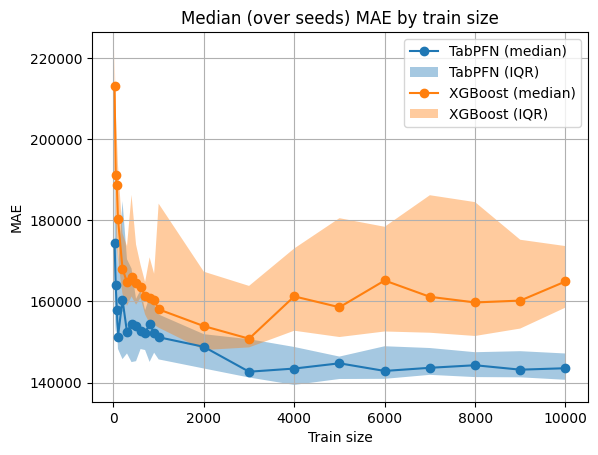

In [10]:
plt.plot(temp.index, temp['tabpfn_median'], label='TabPFN (median)', marker='o')
# fill between IQR
plt.fill_between(temp.index, temp['tabpfn_q25'], temp['tabpfn_q75'], alpha=0.4, label='TabPFN (IQR)')

plt.plot(temp.index, temp['xgboost_median'], label='XGBoost (median)', marker='o')
plt.fill_between(temp.index, temp['xgboost_q25'], temp['xgboost_q75'], alpha=0.4, label='XGBoost (IQR)')
plt.legend()
plt.grid()

plt.xlabel('Train size')
plt.ylabel('MAE')
plt.title('Median (over seeds) MAE by train size')
# plt.savefig('../results/figures/median_mae_by_train_size.png', dpi=300)
plt.show()


# optuna-upto100Ktrain-dropped-columns-20-seeds (just XGBoost)

In [13]:
df = pd.read_csv('../results/optuna-upto100Ktrain-dropped-columns-20-seeds/xgboost.csv')

In [23]:
def get_median_mae(df):

    def q25(x):
        return x.quantile(0.25)
    def q75(x):
        return x.quantile(0.75)

    temp = df.groupby('train_size').agg({'mae': ['mean', 'median', q25, q75]})
    temp.columns = ['xgboost_mean', 'xgboost_median', 'xgboost_q25', 'xgboost_q75']
    return temp

In [ ]:
temp = get_median_mae(df)

In [24]:
def plot_median_mae(temp, title=''):
    plt.plot(temp.index, temp['xgboost_median'], label='XGBoost (median)', marker='o')

    # fill_between IQR
    plt.fill_between(temp.index, temp['xgboost_q25'], temp['xgboost_q75'], alpha=0.4, label='XGBoost (IQR)')
    plt.legend()
    plt.grid()

    plt.xlabel('Train size')
    plt.ylabel('MAE')
    plt.title(title)

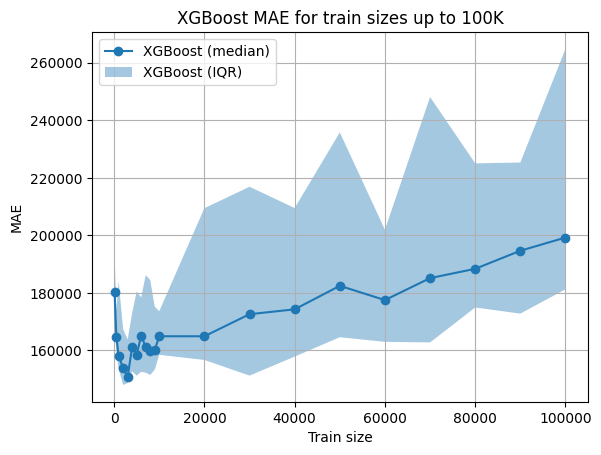

In [25]:
plot_median_mae(temp, title='XGBoost MAE for train sizes up to 100K')

# optuna-only2021train-upto10Ktrain-dropped-columns-20-seeds

In [13]:
df1 = pd.read_csv('../results/optuna-only2021train-upto10Ktrain-dropped-columns-20-seeds/xgboost.csv')
df2 = pd.read_csv('../results/optuna-only2021train-upto10Ktrain-dropped-columns-20-seeds/tabpfn.csv')

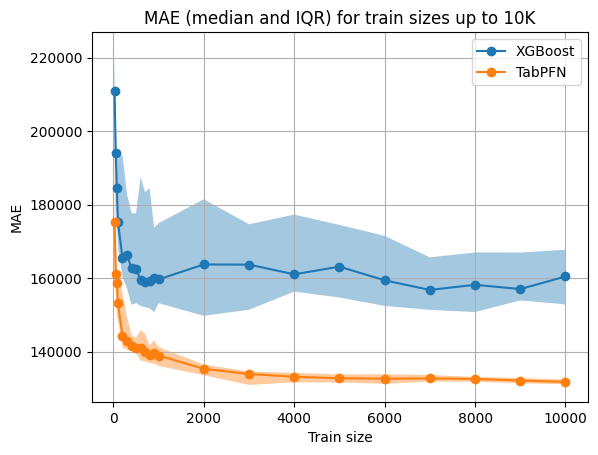

In [18]:
temp1 = get_median_mae(df1)
temp2 = get_median_mae(df2)
plot_median_mae(temp1, label='XGBoost')
plot_median_mae(temp2, title='MAE (median and IQR) for train sizes up to 10K', label='TabPFN')
plt.grid()

# optuna-notemporal-upto10Ktrain-dropped-columns-20-seeds

In [19]:
df1 = pd.read_csv('../results/optuna-notemporal-upto10Ktrain-dropped-columns-20-seeds/xgboost.csv')
df2 = pd.read_csv('../results/optuna-notemporal-upto10Ktrain-dropped-columns-20-seeds/tabpfn.csv')

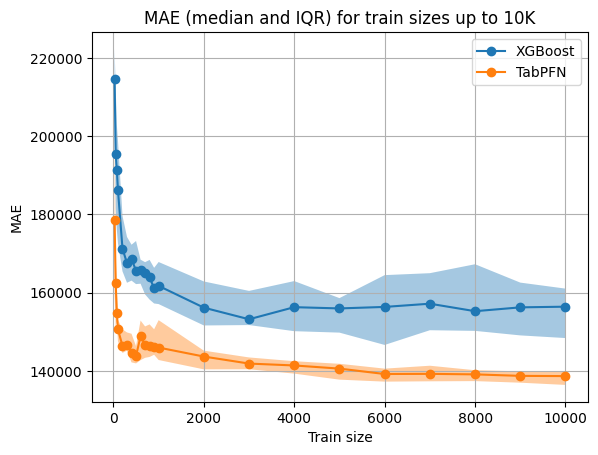

In [20]:
temp1 = get_median_mae(df1)
temp2 = get_median_mae(df2)
plot_median_mae(temp1, label='XGBoost')
plot_median_mae(temp2, title='MAE (median and IQR) for train sizes up to 10K', label='TabPFN')
plt.grid()


In [ ]:
# Train XGBoost on ALL available training data to see the limit of performance
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '/sailhome/salilg/tabpfn_data_scarcity/cook_county_analysis')

from src.data_utils import load_and_prepare_data, prepare_features_for_model
from src.model_runners import XGBoostRunner
from src.evaluation import calculate_metrics

print("="*80)
print("Training XGBoost on ALL available training data")
print("="*80)
print()

# Load data
print("Loading data...")
X_train_pool, y_train_pool, X_test, y_test, cbg_column = load_and_prepare_data(
    '../data/cook_county.csv', 'block_group_id'
)

print(f"Train pool size: {len(X_train_pool):,}")
print(f"Test set size: {len(X_test):,}")
print(f"Number of features: {len(X_train_pool.columns)}")
print()

# Prepare features (drop CBG column)
print("Preparing features...")
X_train_model = prepare_features_for_model(X_train_pool, cbg_column, keep_cbg=False)
X_test_model = prepare_features_for_model(X_test, cbg_column, keep_cbg=False)

print(f"Features after dropping CBG: {X_train_model.shape[1]}")
print()

# Train XGBoost with hyperparameter tuning
print("Training XGBoost with hyperparameter tuning (n_iter=10, cv=3)...")
print("This may take a few minutes...")
model_runner = XGBoostRunner(n_iter=10, cv=3, use_gpu=True, random_state=42)
model_runner.fit(X_train_model, y_train_pool)

print(f"Training complete! Tuning time: {model_runner.get_tune_time():.2f}s")
print(f"Best hyperparameters: {model_runner.best_params}")
print()

# Predict on test set
print("Making predictions on test set...")
y_pred = model_runner.predict(X_test_model)

# Calculate metrics
metrics = calculate_metrics(y_test, y_pred)

print()
print("="*80)
print("RESULTS: XGBoost trained on ALL training data")
print("="*80)
print(f"Training size: {len(X_train_pool):,} samples")
print(f"Test size: {len(X_test):,} samples")
print()
print(f"MAE:  ${metrics['mae']:,.2f}")
print(f"MSE:  {metrics['mse']:,.2f}")
print(f"R²:   {metrics['r2']:.4f}")
print(f"Mean Ratio:   {metrics['mean_ratio']:.4f}")
print(f"Median Ratio: {metrics['median_ratio']:.4f}")
print()
print("For comparison:")
print("  - At train_size=10,000: median MAE was ~$207k")
print("  - At train_size=1,000:  median MAE was ~$163k")
print("="*80)

# Cleanup
model_runner.cleanup()

# Compare XGBoost modeling choices

In [3]:
df1 = pd.read_csv('../results/optuna-upto10Ktrain-dropped-columns-20-seeds/xgboost.csv')
df2 = pd.read_csv('../results/optuna-only2021train-upto10Ktrain-dropped-columns-20-seeds/xgboost.csv')
df3 = pd.read_csv('../results/optuna-notemporal-upto10Ktrain-dropped-columns-20-seeds/xgboost.csv')

In [2]:
df4 = pd.read_csv('../results/evelyn-includepropertychars-20-seeds/xgboost.csv')
df5 = pd.read_csv('../results/evelyn-nopropertychars-20-seeds/xgboost.csv')

df6 = pd.read_csv('../results/tabpfn-includepropertychars-20-seeds/tabpfn.csv')
df7 = pd.read_csv('../results/tabpfn-nopropertychars-20-seeds/tabpfn.csv')


In [2]:
df8 = pd.read_csv('../results/propertyonly-original-20seeds/xgboost.csv')
df9 = pd.read_csv('../results/propertyonly-original-20seeds/tabpfn.csv')

In [3]:
def get_median_mae(df):

    def q25(x):
        return x.quantile(0.25)
    def q75(x):
        return x.quantile(0.75)

    temp = df.groupby('train_size').agg({'mae': ['mean', 'median', q25, q75]})
    temp.columns = ['xgboost_mean', 'xgboost_median', 'xgboost_q25', 'xgboost_q75']
    return temp

def plot_median_mae(temp, title='', label=''):
    plt.plot(temp.index, temp['xgboost_median'], label=label, marker='o')

    # fill_between IQR
    plt.fill_between(temp.index, temp['xgboost_q25'], temp['xgboost_q75'], alpha=0.4)
    plt.legend()
    plt.grid()

    plt.xlabel('Train size')
    plt.ylabel('MAE')
    plt.title(title)

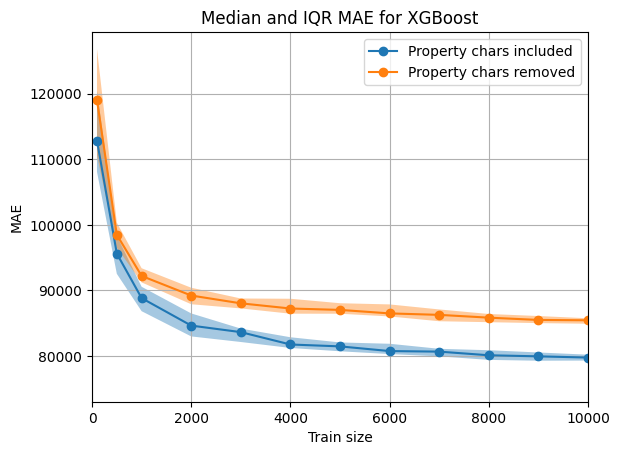

In [28]:
temp1 = get_median_mae(df1)
temp2 = get_median_mae(df2)
temp3 = get_median_mae(df3)
temp4 = get_median_mae(df4)
temp5 = get_median_mae(df5)

# plot_median_mae(temp1, label='All training data')
# plot_median_mae(temp2, label='Only 2021 training data')
# plot_median_mae(temp3, label='Temporal features removed')
plot_median_mae(temp4, label='Property chars included')
plot_median_mae(temp5, label='Property chars removed')
plt.title('Median and IQR MAE for XGBoost')
plt.xlim(0, 10000)
plt.grid()

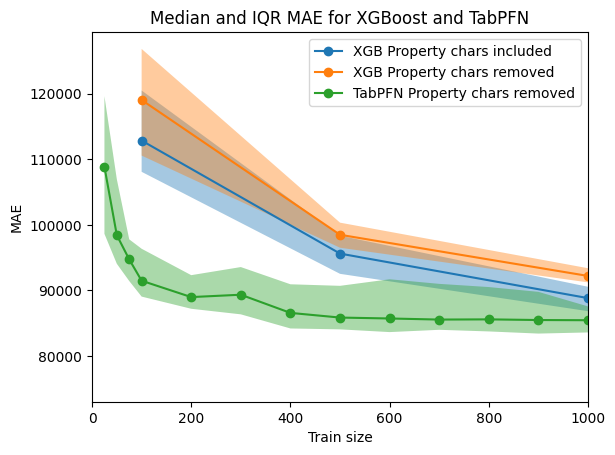

In [14]:
temp4 = get_median_mae(df4)
temp5 = get_median_mae(df5)
temp6 = get_median_mae(df6)
temp7 = get_median_mae(df7)

# plot_median_mae(temp1, label='All training data')
# plot_median_mae(temp2, label='Only 2021 training data')
# plot_median_mae(temp3, label='Temporal features removed')
plot_median_mae(temp4, label='XGB Property chars included')
plot_median_mae(temp5, label='XGB Property chars removed')
# plot_median_mae(temp6, label='TabPFN Property chars included')
plot_median_mae(temp7, label='TabPFN Property chars removed')
plt.title('Median and IQR MAE for XGBoost and TabPFN')
plt.xlim(0, 1000)
plt.grid()



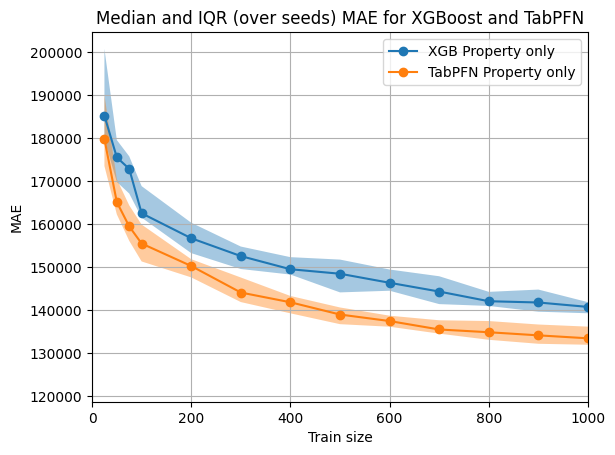

In [4]:
temp8 = get_median_mae(df8)
temp9 = get_median_mae(df9)
plot_median_mae(temp8, label='XGB Property only')
plot_median_mae(temp9, label='TabPFN Property only')
plt.title('Median and IQR (over seeds) MAE for XGBoost and TabPFN')
plt.xlim(0, 1000)
plt.grid()
